In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
import seaborn as sns
sns.set_theme(style="whitegrid")


In [2]:
#Para tranformar las variables categóricas a numéricas
from sklearn import preprocessing
le = preprocessing.LabelEncoder()

In [3]:
#Para evitar los warnings
import warnings
warnings.filterwarnings('ignore')

In [4]:
#Añadir el color a la terminal
class color:
   PURPLE = '\033[95m'
   CYAN = '\033[96m'
   DARKCYAN = '\033[36m'
   BLUE = '\033[94m'
   GREEN = '\033[92m'
   YELLOW = '\033[93m'
   RED = '\033[91m'
   BOLD = '\033[1m'
   UNDERLINE = '\033[4m'
   END = '\033[0m'

In [5]:
ruta_archivo = os.path.join('..','data', 'CarPrice_Assignment.csv')
df = pd.read_csv(ruta_archivo)
df.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [6]:
#Eliminado las primeras columnas que no aportan información relevante para el análisis
df=df.drop(columns=['car_ID','symboling'])

In [7]:
#Poner a mayúscula el primer caracter.
df.columns=[attr.title() for attr in df.columns]

In [8]:
#Viendo el tipo de dato de cada columna
for i,attr in enumerate(df.columns,start=1):
    if df[attr].dtype == "str":
        print(color.YELLOW+color.BOLD +'{0:>2}.{1:<20} {2}'.format(i,attr +":","str")+color.END)
    elif df[attr].dtype == "int64":
        print(color.RED+color.BOLD +'{0:>2}.{1:<20} {2}'.format(i,attr +":","int64")+color.END)
    else:
        print(color.BLUE+color.BOLD +'{0:>2}.{1:<20} {2}'.format(i,attr +":","float64")+color.END)       

 1.Carname:             str
 2.Fueltype:            str
 3.Aspiration:          str
 4.Doornumber:          str
 5.Carbody:             str
 6.Drivewheel:          str
 7.Enginelocation:      str
 8.Wheelbase:           float64
 9.Carlength:           float64
10.Carwidth:            float64
11.Carheight:           float64
12.Curbweight:          int64
13.Enginetype:          str
14.Cylindernumber:      str
15.Enginesize:          int64
16.Fuelsystem:          str
17.Boreratio:           float64
18.Stroke:              float64
19.Compressionratio:    float64
20.Horsepower:          int64
21.Peakrpm:             int64
22.Citympg:             int64
23.Highwaympg:          int64
24.Price:               float64


In [9]:
#Viendo si hay valores nulos en el DataFrame
df.isnull().any()

Carname             False
Fueltype            False
Aspiration          False
Doornumber          False
Carbody             False
Drivewheel          False
Enginelocation      False
Wheelbase           False
Carlength           False
Carwidth            False
Carheight           False
Curbweight          False
Enginetype          False
Cylindernumber      False
Enginesize          False
Fuelsystem          False
Boreratio           False
Stroke              False
Compressionratio    False
Horsepower          False
Peakrpm             False
Citympg             False
Highwaympg          False
Price               False
dtype: bool

In [10]:
def analysis(attr):
    #2 gráficos
    variables_counted=df[attr].value_counts(ascending=True).sort_index()
    variables_counted_df =pd.DataFrame({"x":variables_counted.index,"y":variables_counted.values})
    dtype= df[attr].dtype
    unique_count = df[attr].nunique()
    plt.figure(figsize=(18,10))
    ax1=plt.subplot(211)
    if (dtype== "float64") or (dtype=="int64" and variables_counted.size>30):
        sns.histplot(data=df[attr], bins=100)
        ax1.set(xlabel="",ylabel="")
        ax2=plt.subplot(212,sharex=ax1)
        sns.scatterplot(data=df, x=attr, y="Price")
    elif dtype=="str":
        order = variables_counted_df["x"].tolist()
        # Crear un mapeo de colores consistente
        unique_attrs = df[attr].unique()
        colors = sns.color_palette('viridis', n_colors=len(unique_attrs))
        color_map = {attr_val: colors[i] for i, attr_val in enumerate(sorted(unique_attrs))}
        
        sns.barplot(data=variables_counted_df, x="y", y="x", hue="x", palette=color_map, legend=False, order=order)
        ax1.set(xlabel="",ylabel="")
        ax2=plt.subplot(212)
        sns.boxplot(data=df, y='Price', x=attr, hue=attr, palette=color_map, legend=False, order=order)
    else:
        # Para variables numéricas discretas con pocos valores únicos, usar colores por categoría
        if unique_count <= 20:
            order = variables_counted_df["x"].tolist()
            unique_attrs = sorted(df[attr].unique())
            colors = sns.color_palette('viridis', n_colors=len(unique_attrs))
            color_map = {attr_val: colors[i] for i, attr_val in enumerate(unique_attrs)}
            
            sns.barplot(data=variables_counted_df, x="x", y="y", hue="x", palette=color_map, legend=False, order=order)
            ax1.set(xlabel="",ylabel="")
            ax2=plt.subplot(212,sharex=ax1)
            sns.boxplot(data=df, y='Price', x=attr, hue=attr, palette=color_map, legend=False, order=order)
        else:
            # Para variables con muchos valores únicos, no usar colores individuales
            sns.barplot(data=variables_counted_df, x="x", y="y", palette='viridis')
            ax1.set(xlabel="",ylabel="")
            ax2=plt.subplot(212,sharex=ax1)
            sns.boxplot(data=df, y='Price', x=attr, palette='viridis')
    ax2.set(xlabel="")
    plt.suptitle(attr,fontsize=18,fontweight="bold")
    plt.show()
    # Número de correlación
    df_temp = df[[attr,'Price']].copy()
    if dtype == 'str' :
        df_temp[attr]=le.fit_transform(df_temp[attr])
    corr=df_temp.corr().iloc[0,1]
    print(color.PURPLE+ 'CORRELACIÓN:'+ color.END)
    print("{0} y Price: {1}".format(attr,round(corr,2)))

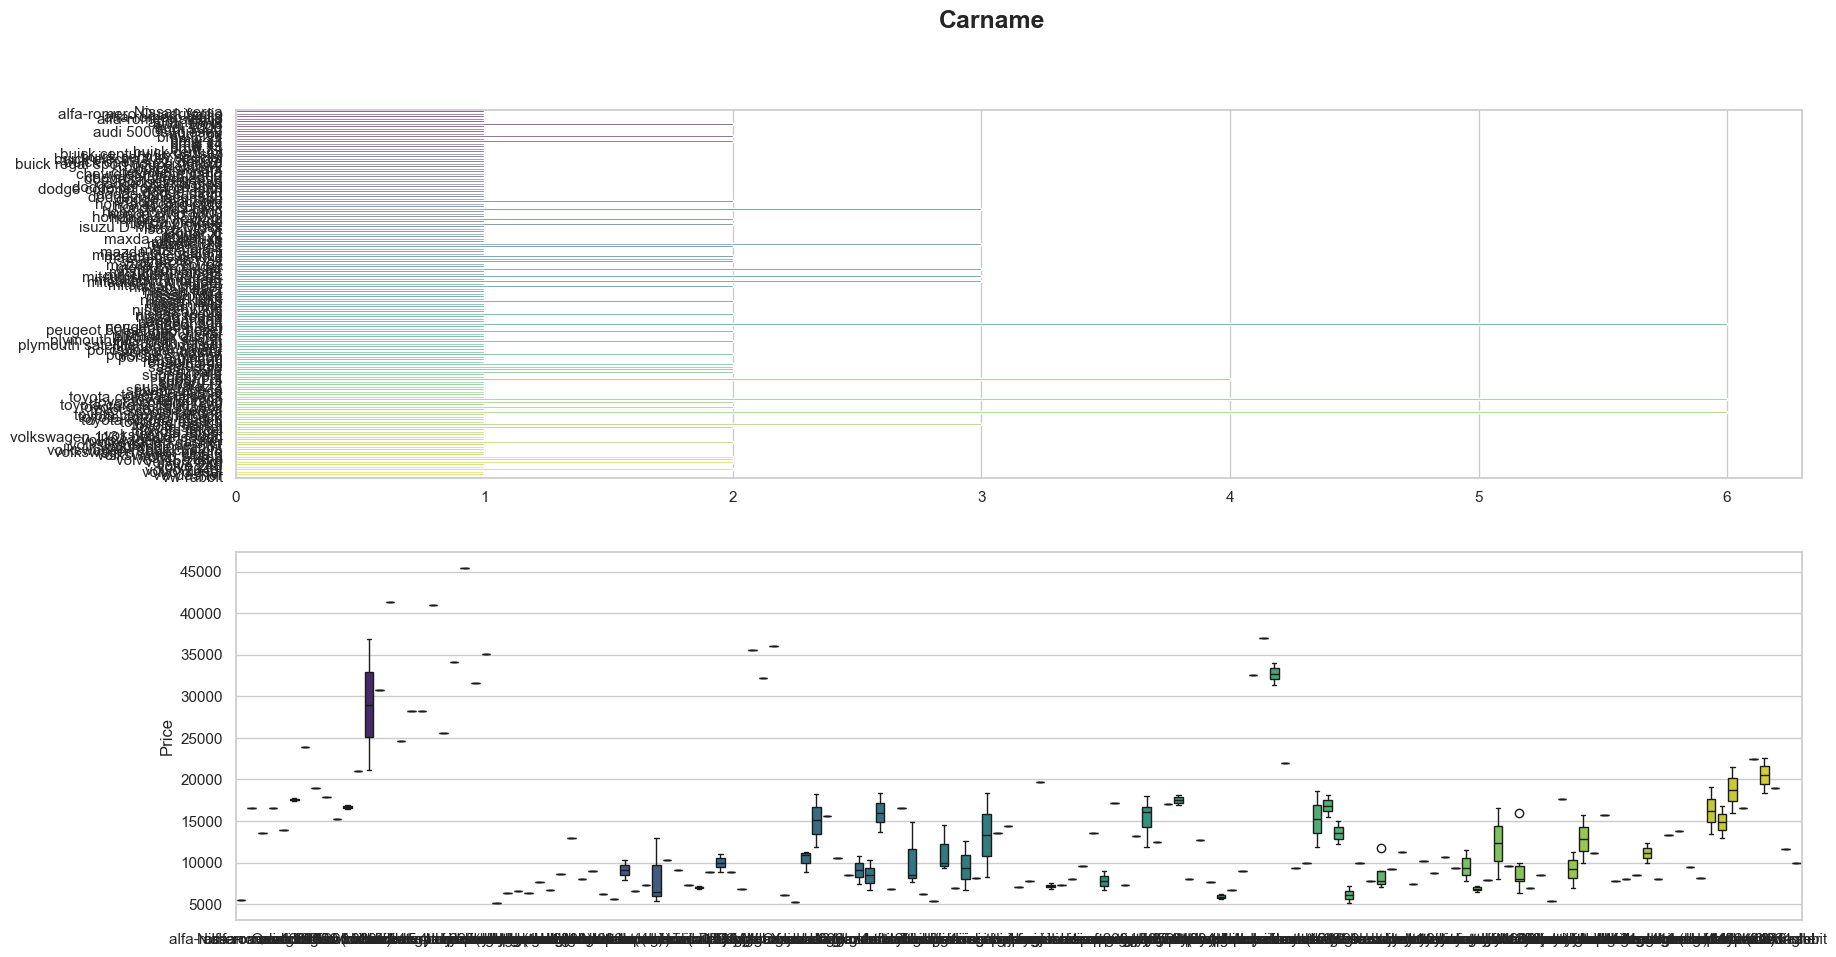

CORRELACIÓN:
Carname y Price: -0.23


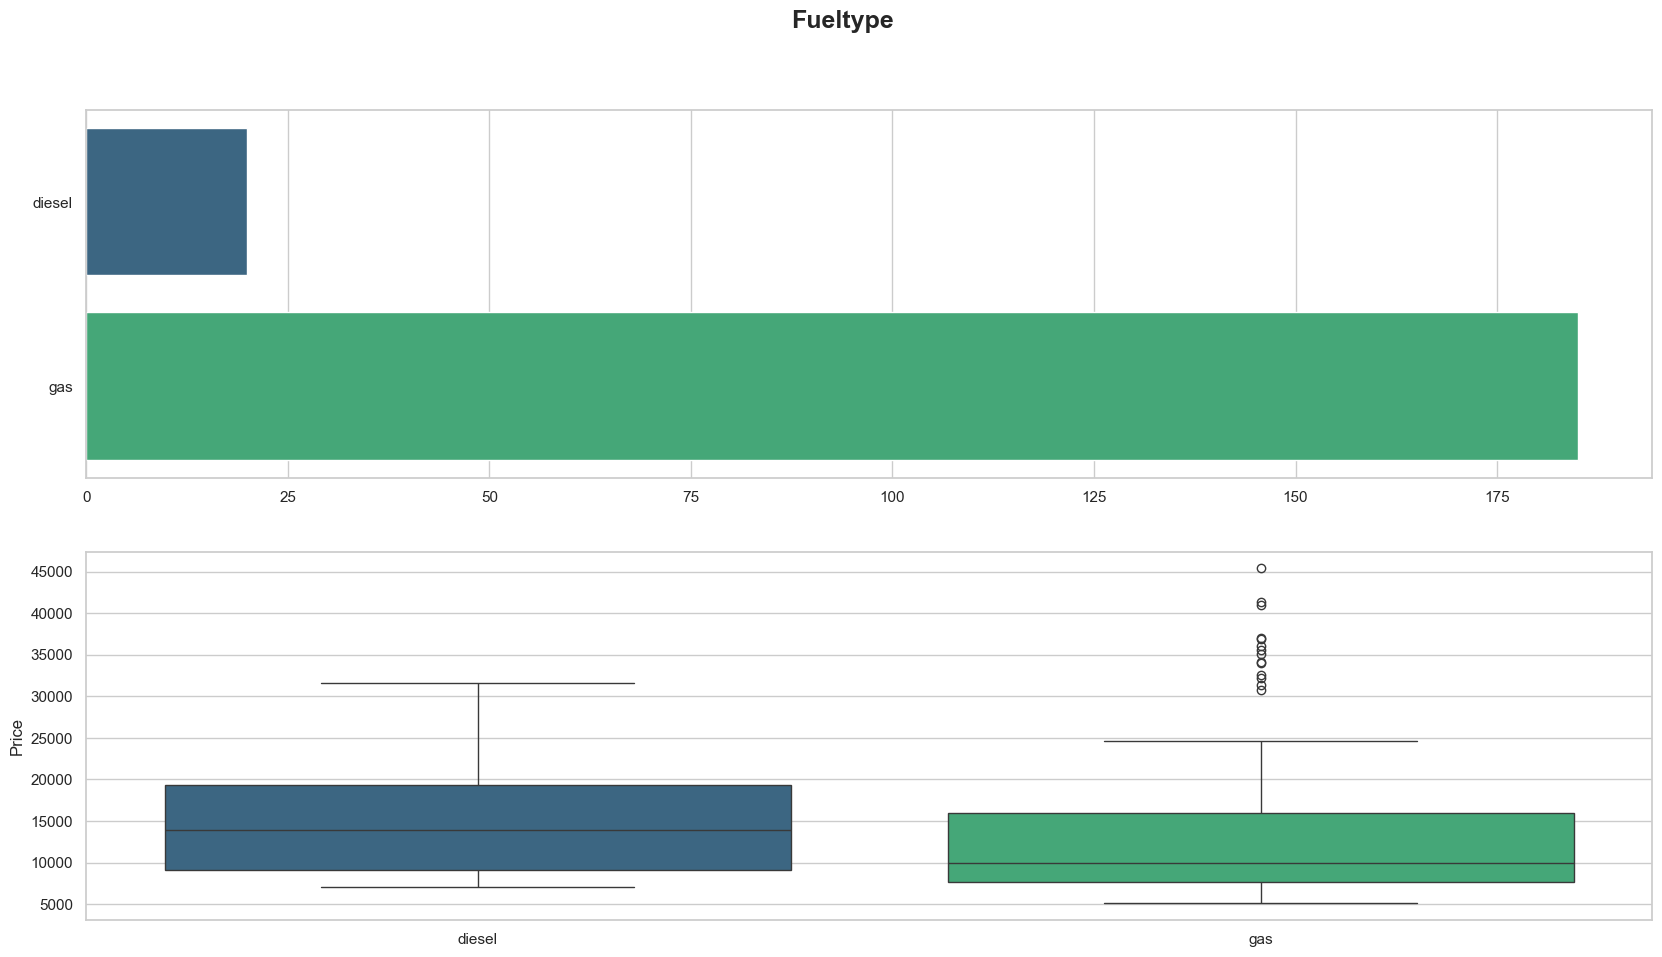

CORRELACIÓN:
Fueltype y Price: -0.11


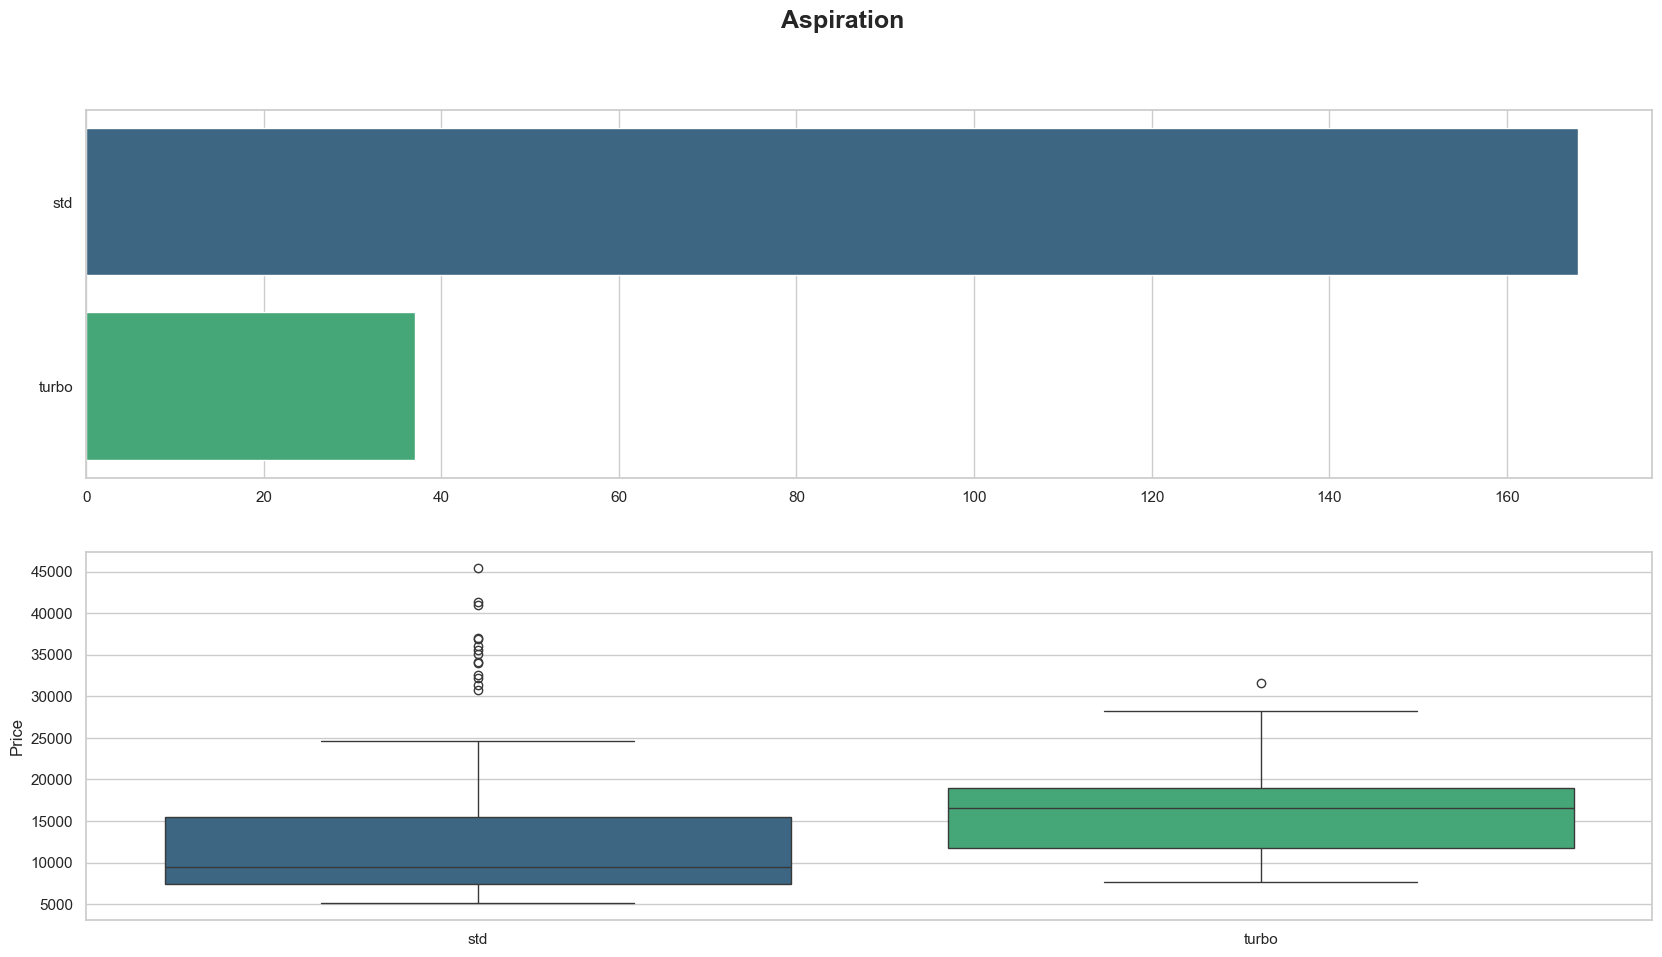

CORRELACIÓN:
Aspiration y Price: 0.18


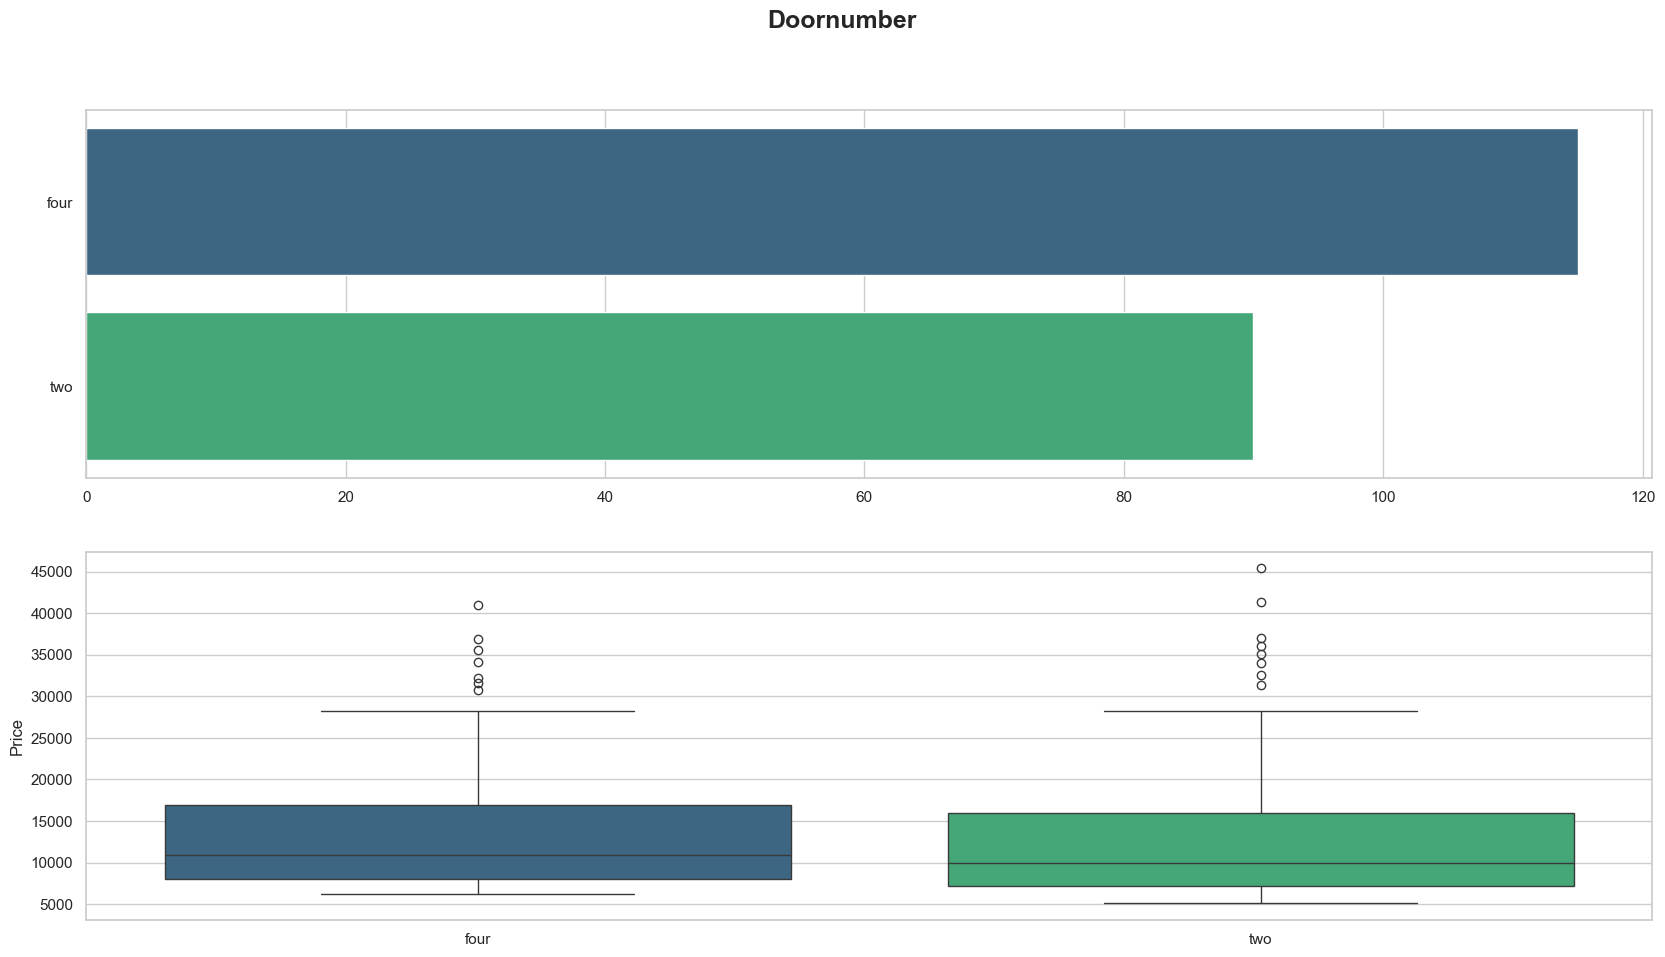

CORRELACIÓN:
Doornumber y Price: -0.03


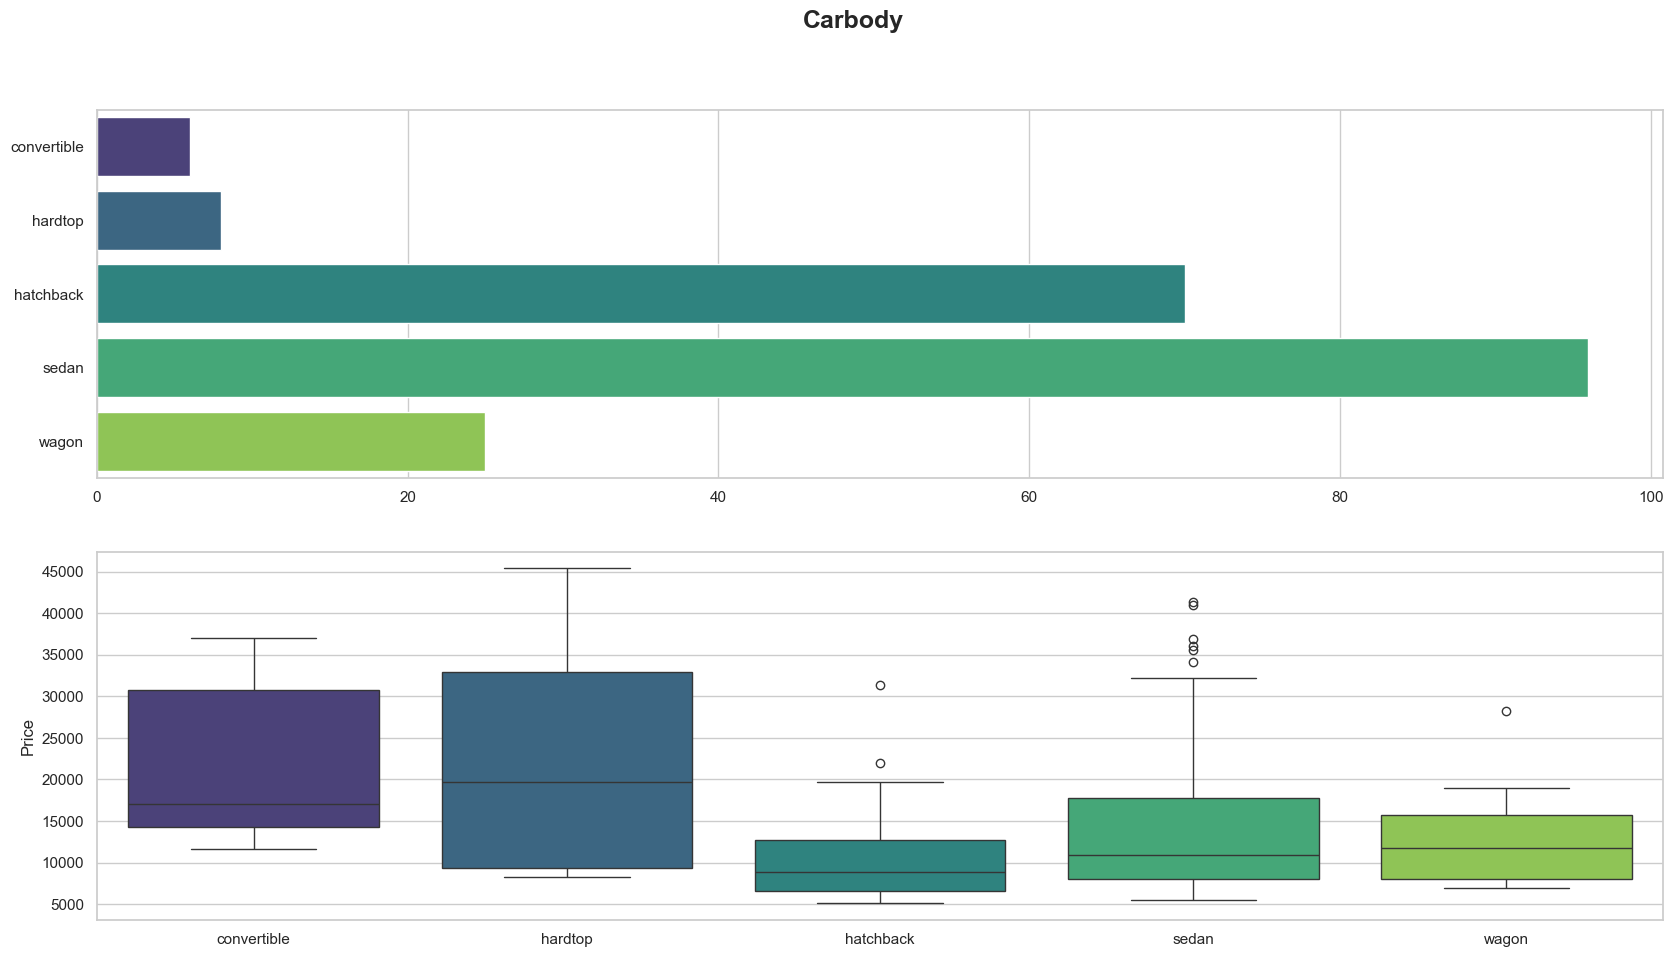

CORRELACIÓN:
Carbody y Price: -0.08


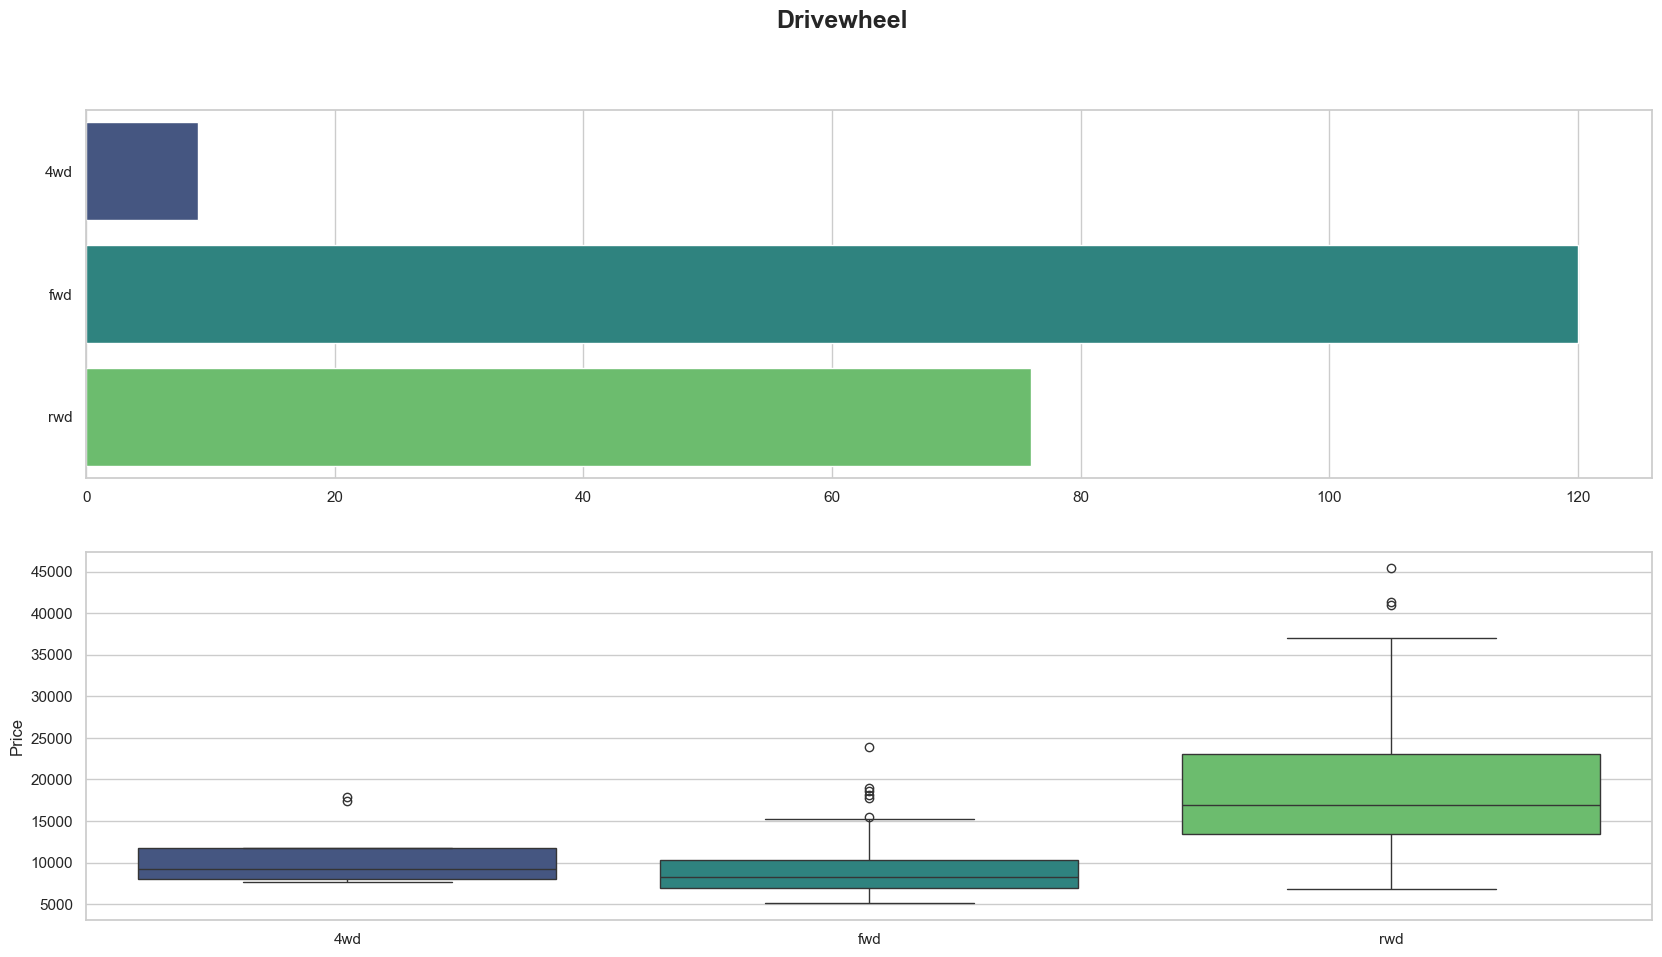

CORRELACIÓN:
Drivewheel y Price: 0.58


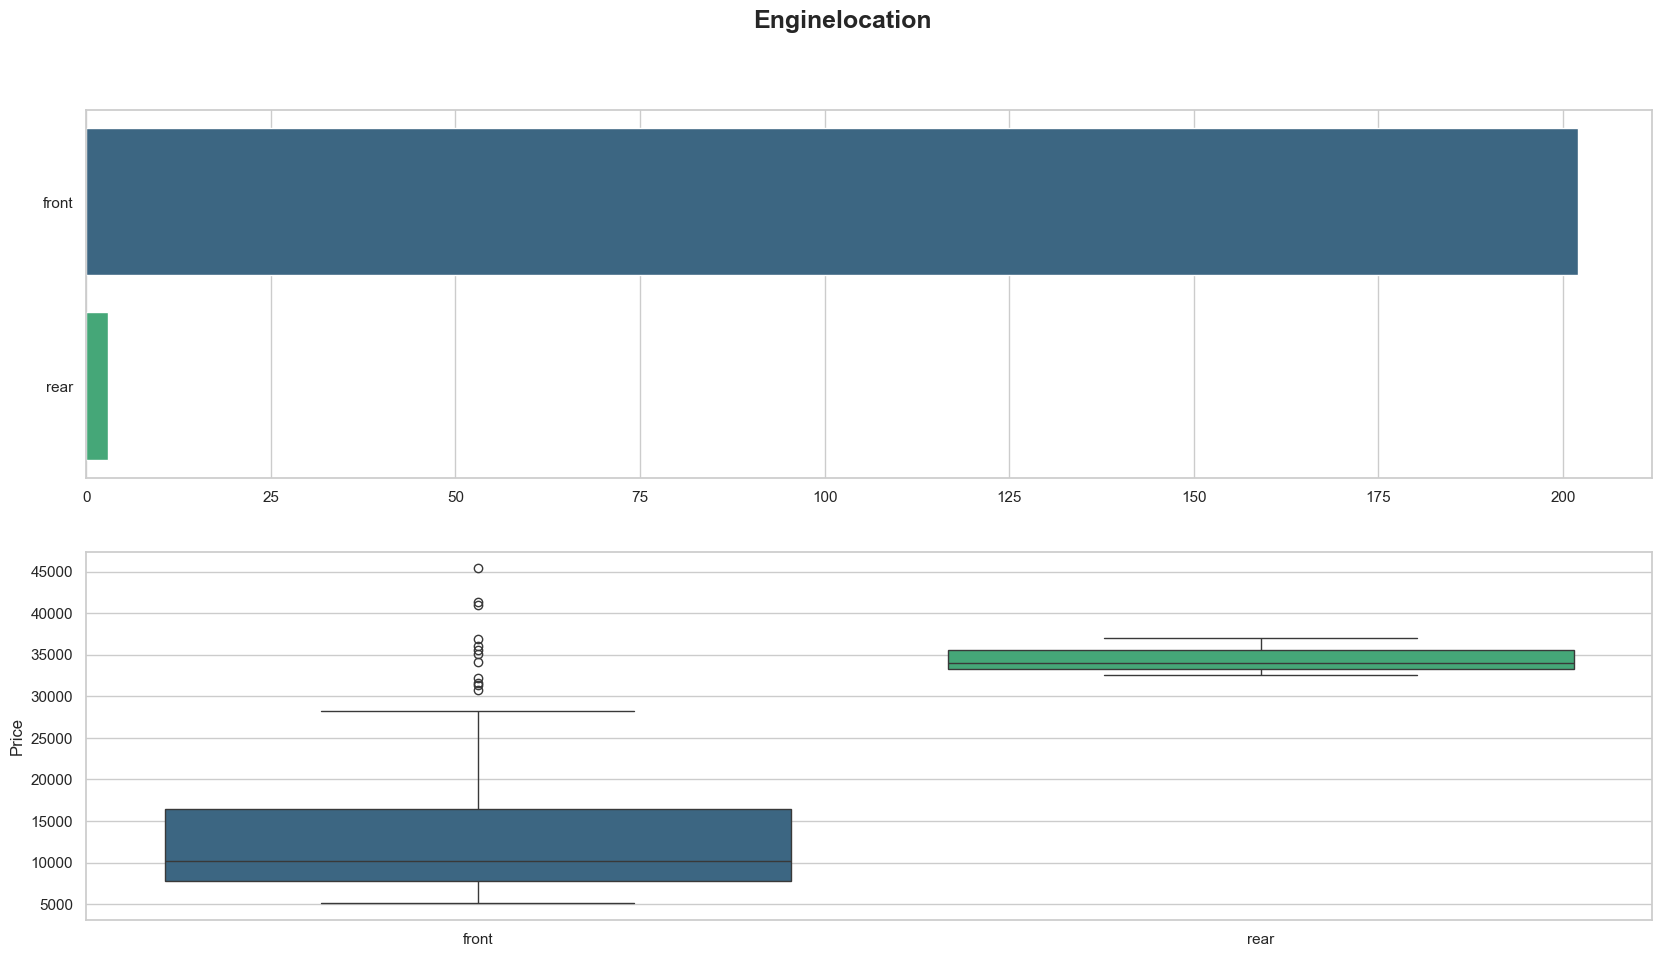

CORRELACIÓN:
Enginelocation y Price: 0.32


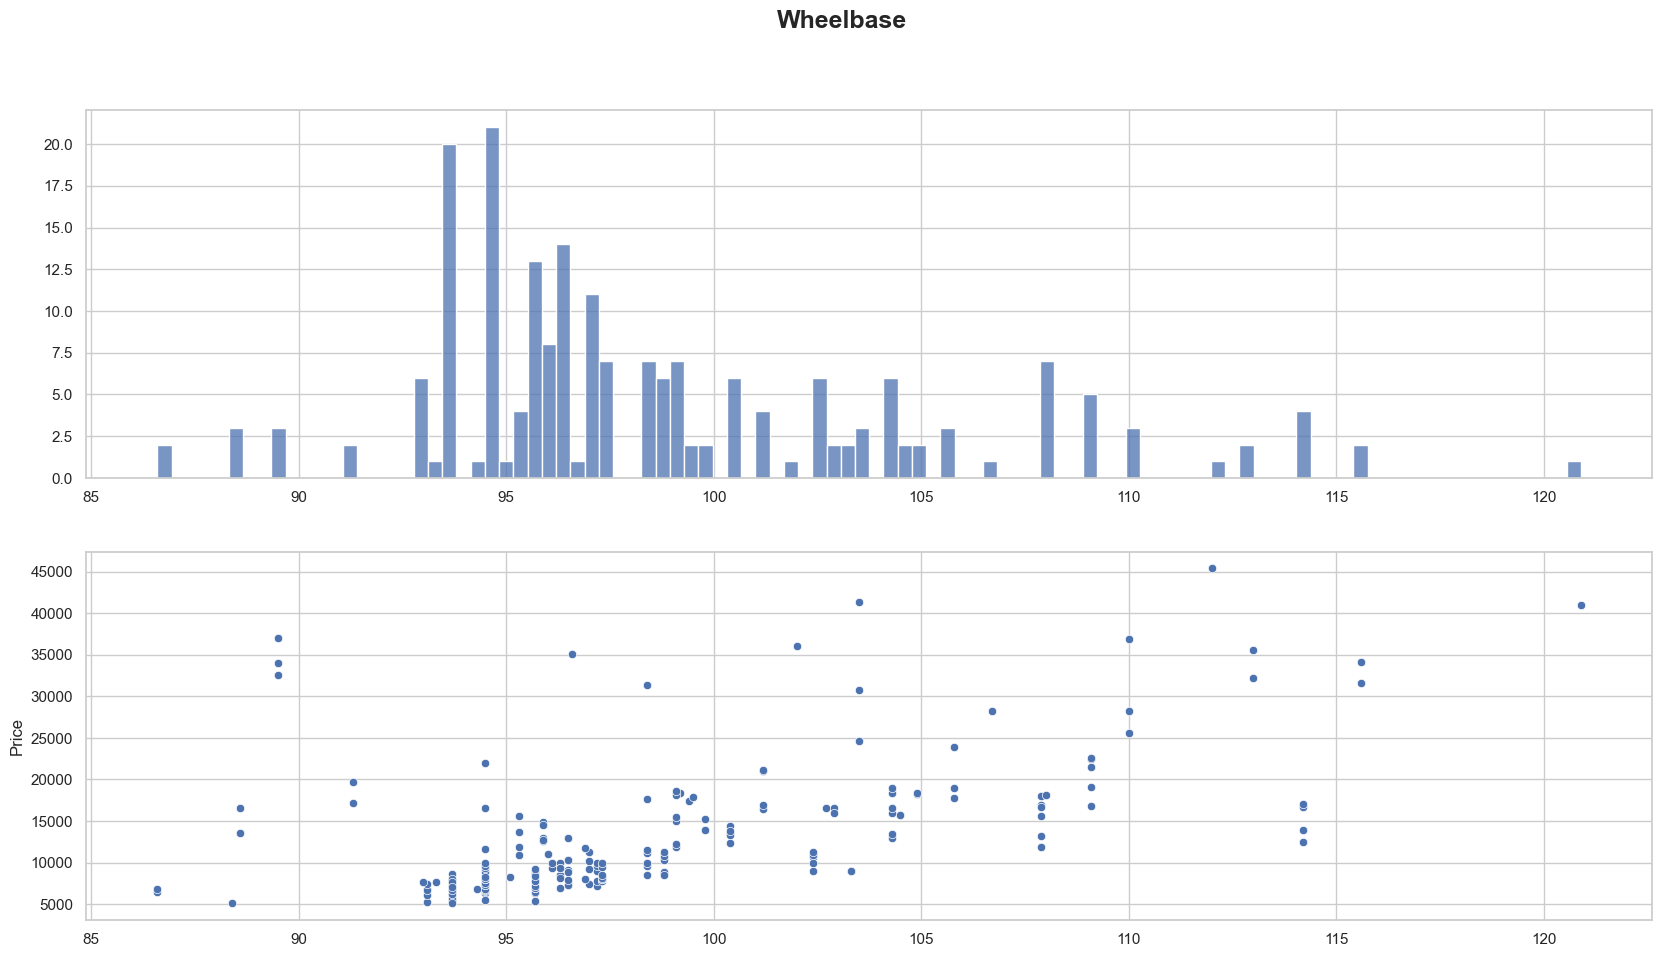

CORRELACIÓN:
Wheelbase y Price: 0.58


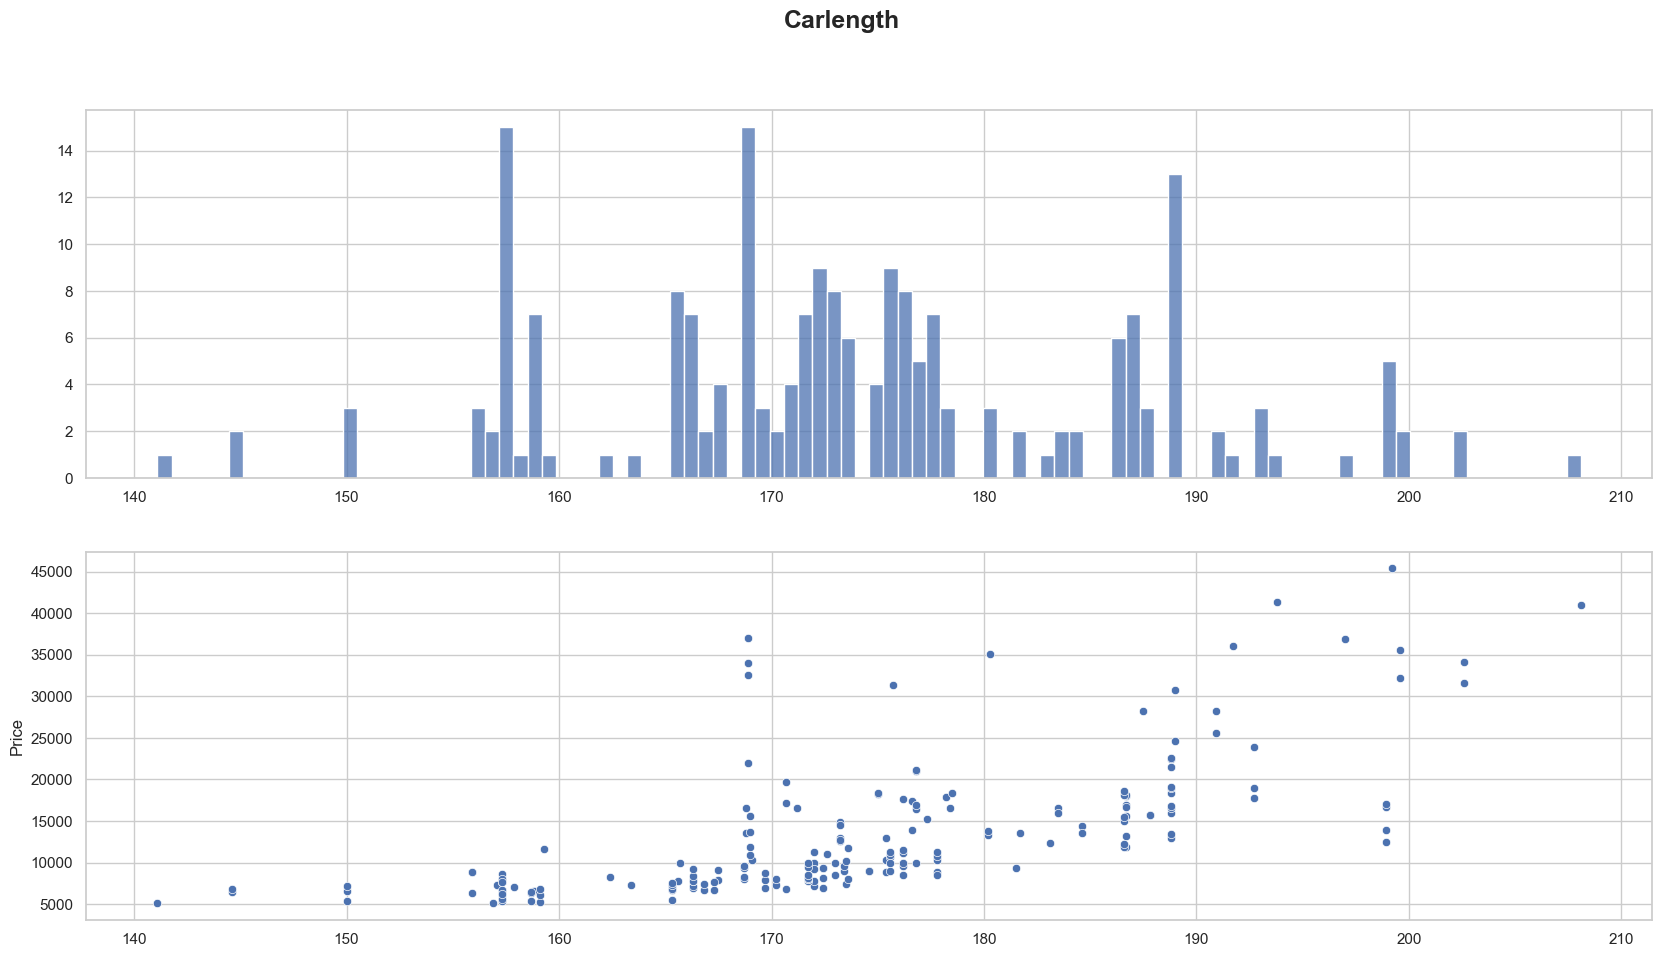

CORRELACIÓN:
Carlength y Price: 0.68


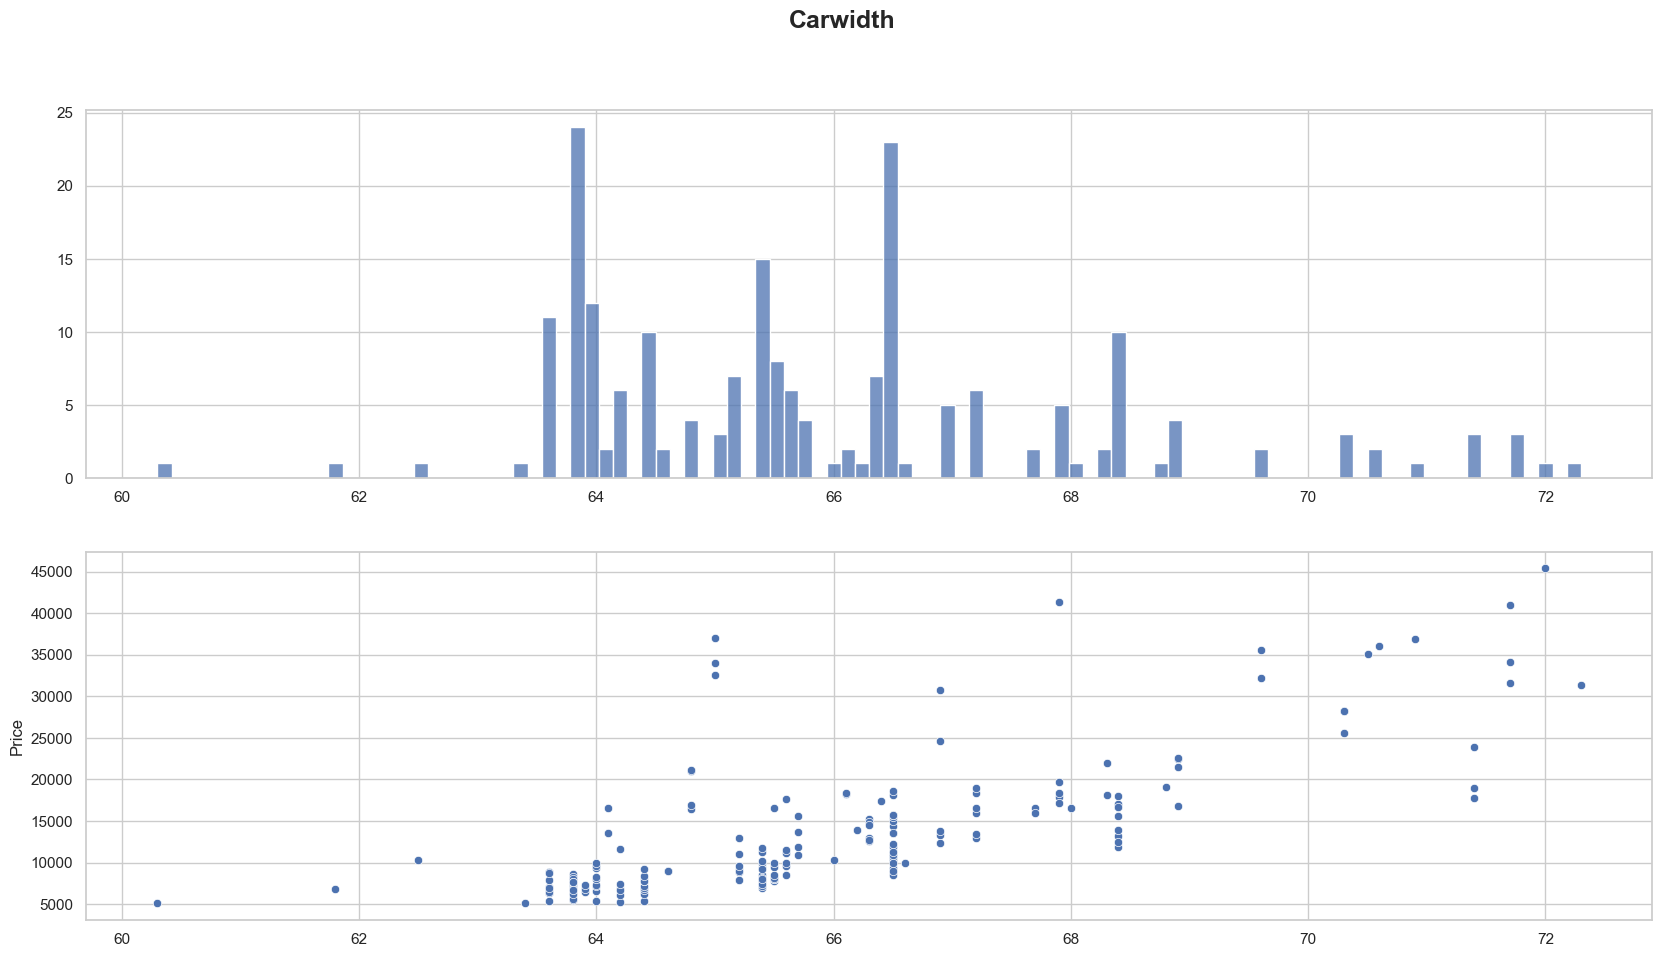

CORRELACIÓN:
Carwidth y Price: 0.76


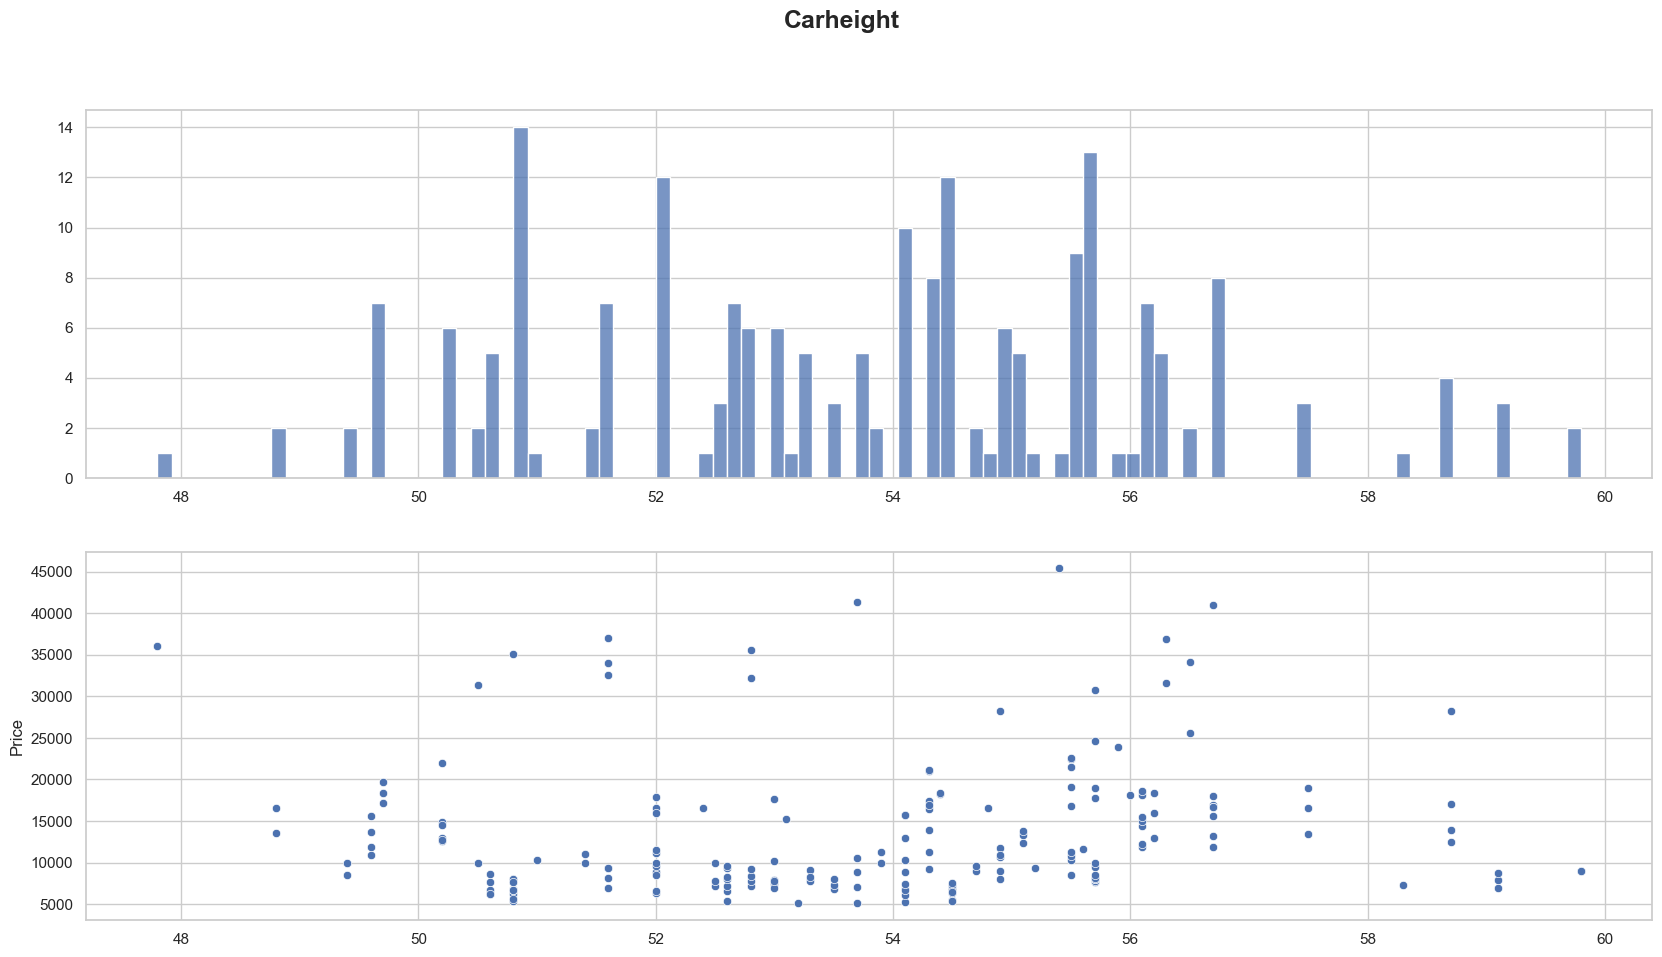

CORRELACIÓN:
Carheight y Price: 0.12


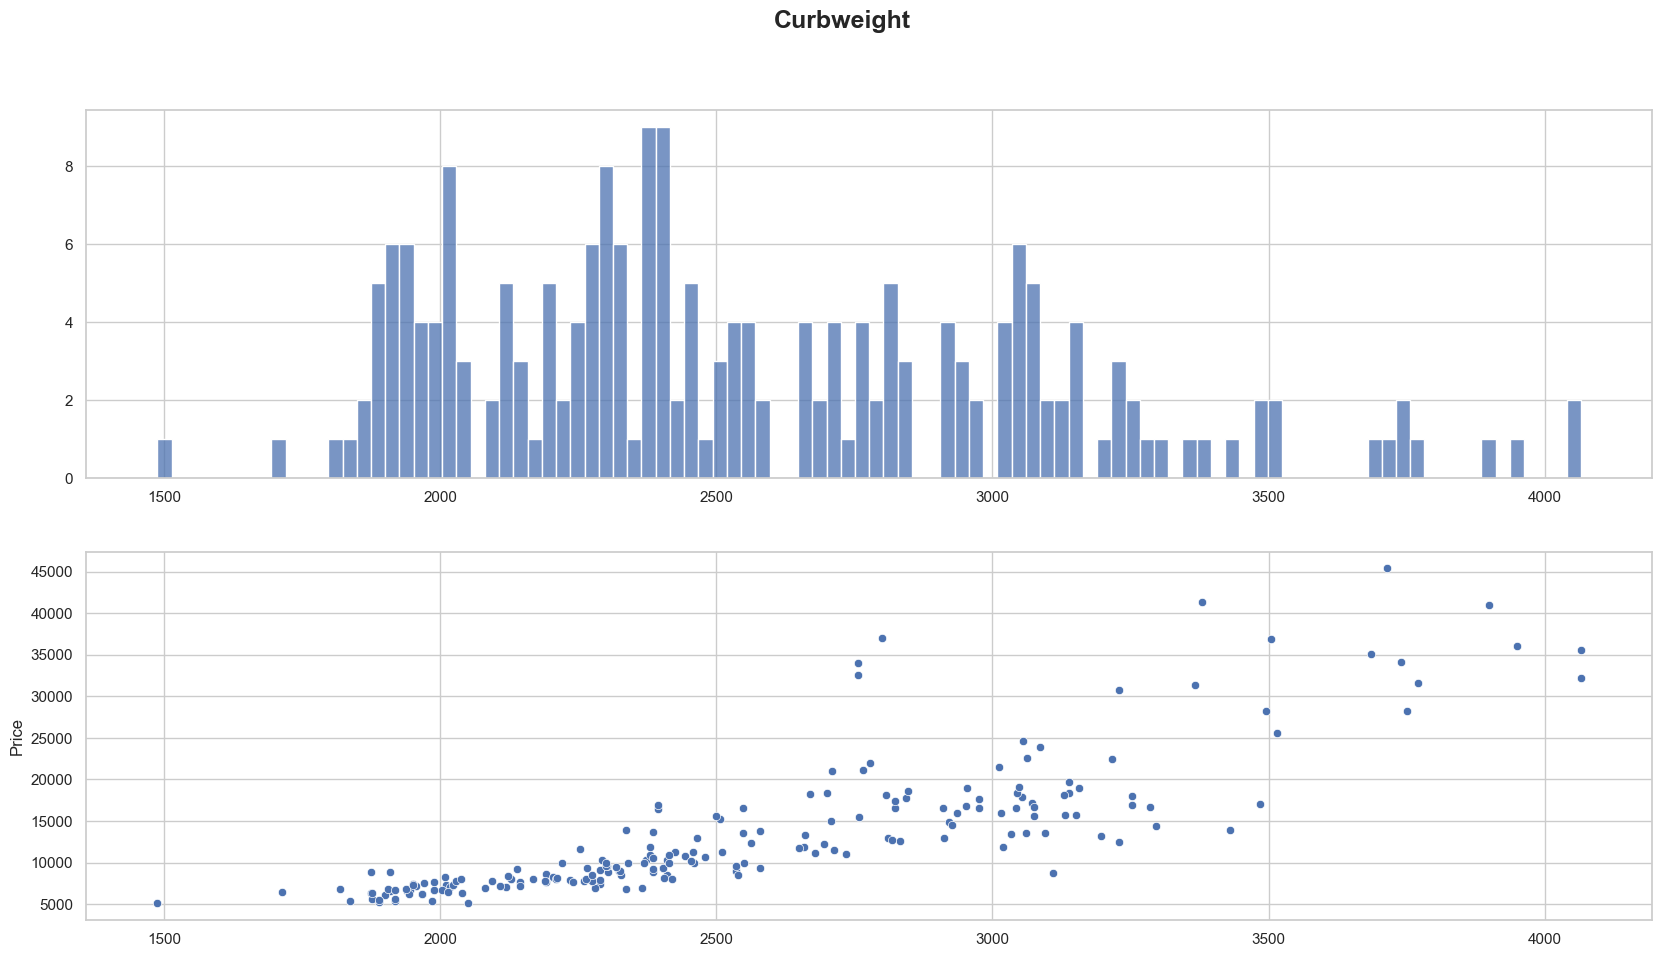

CORRELACIÓN:
Curbweight y Price: 0.84


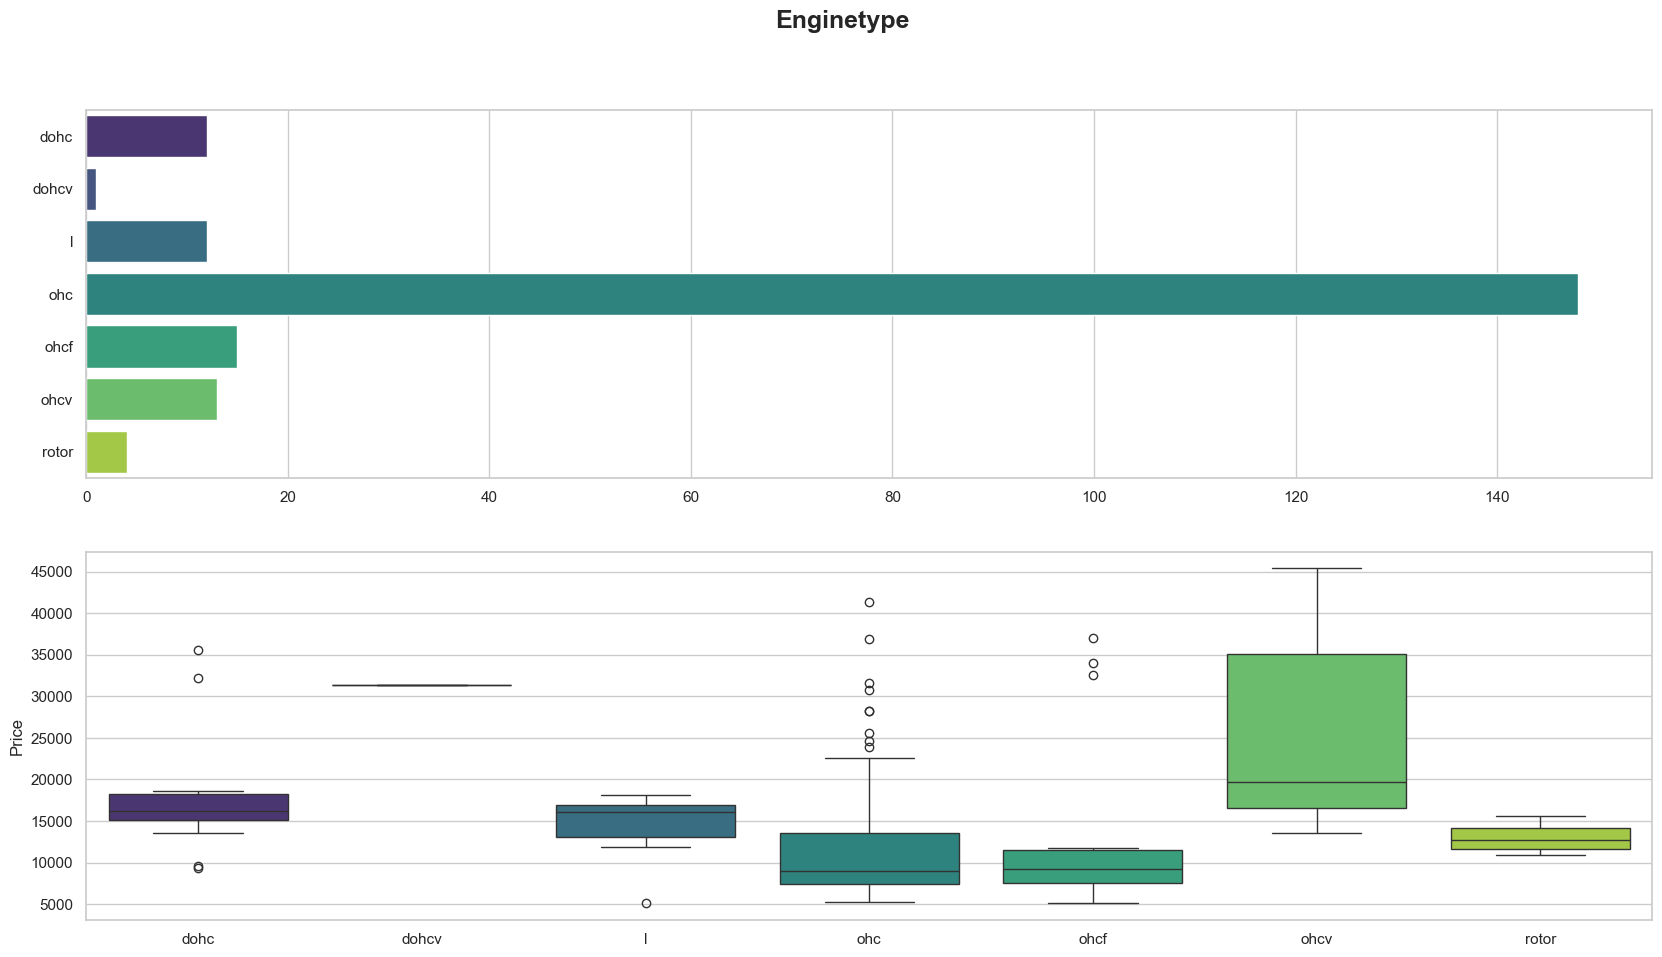

CORRELACIÓN:
Enginetype y Price: 0.05


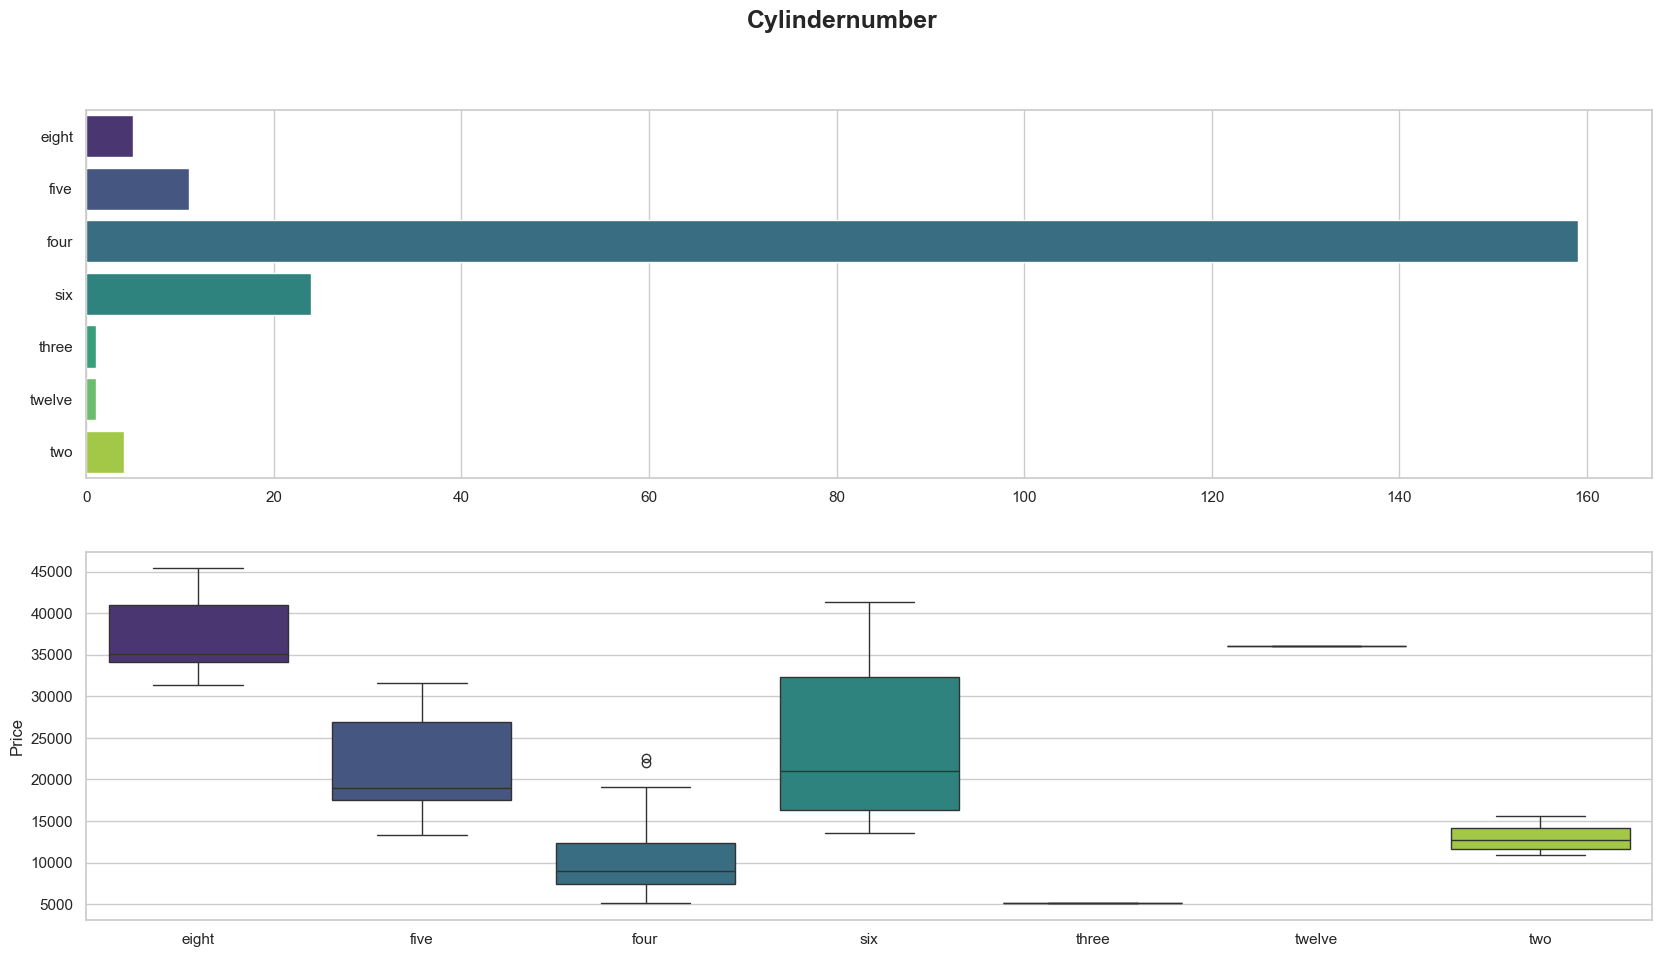

CORRELACIÓN:
Cylindernumber y Price: -0.03


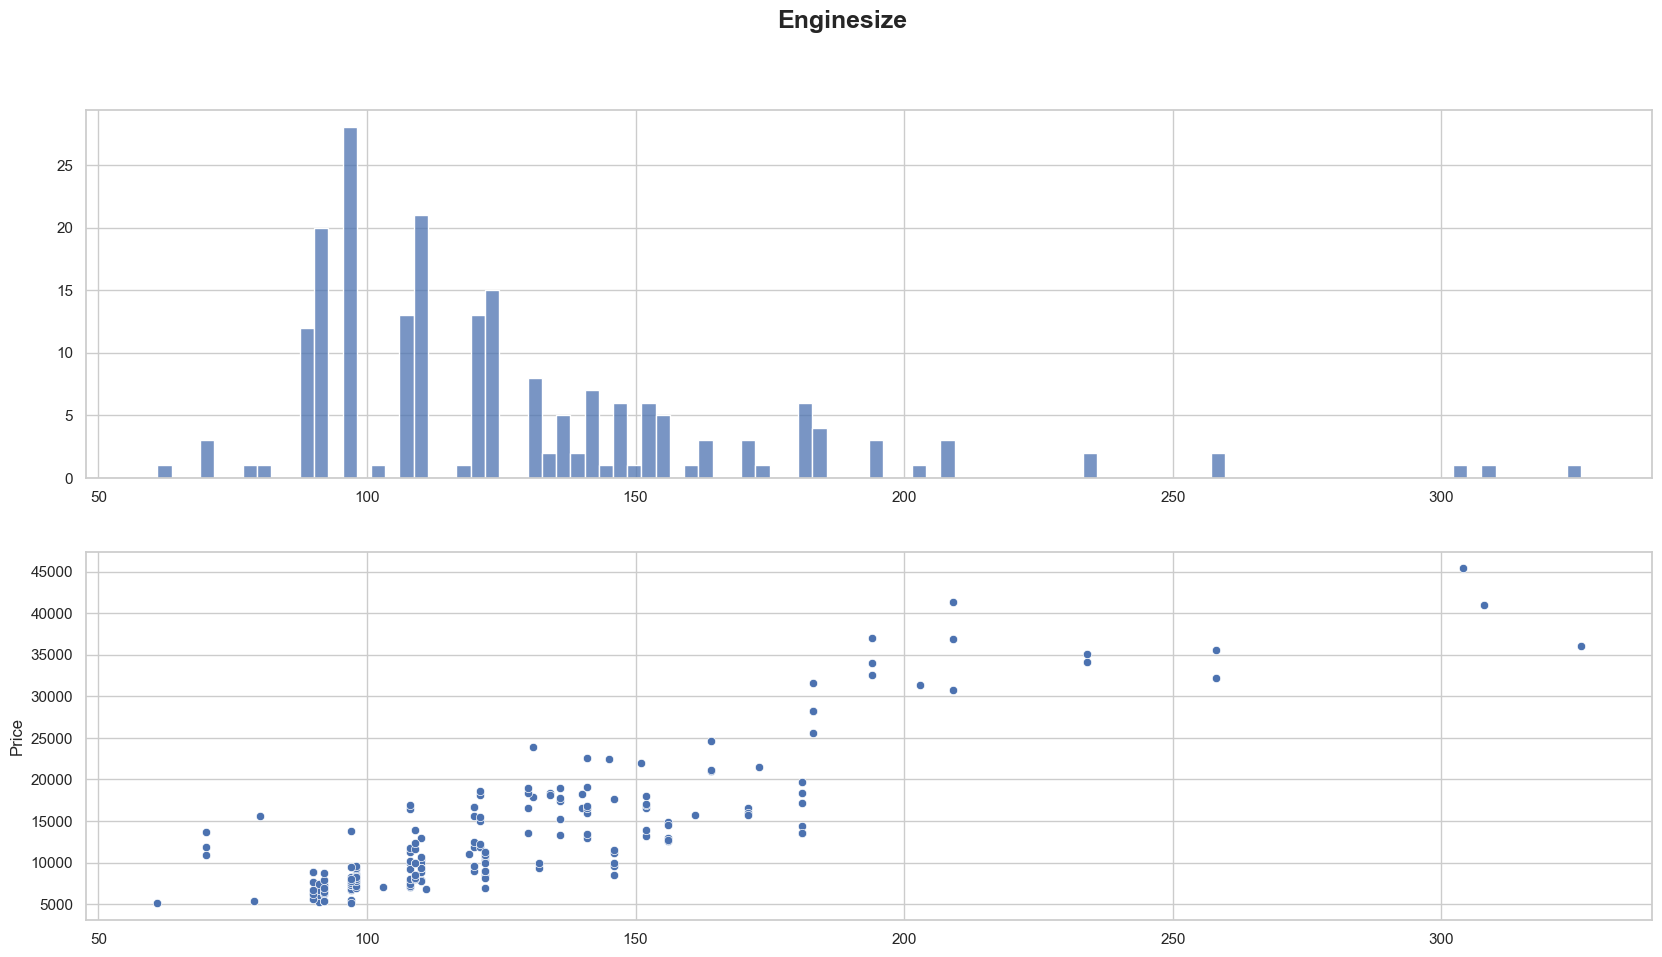

CORRELACIÓN:
Enginesize y Price: 0.87


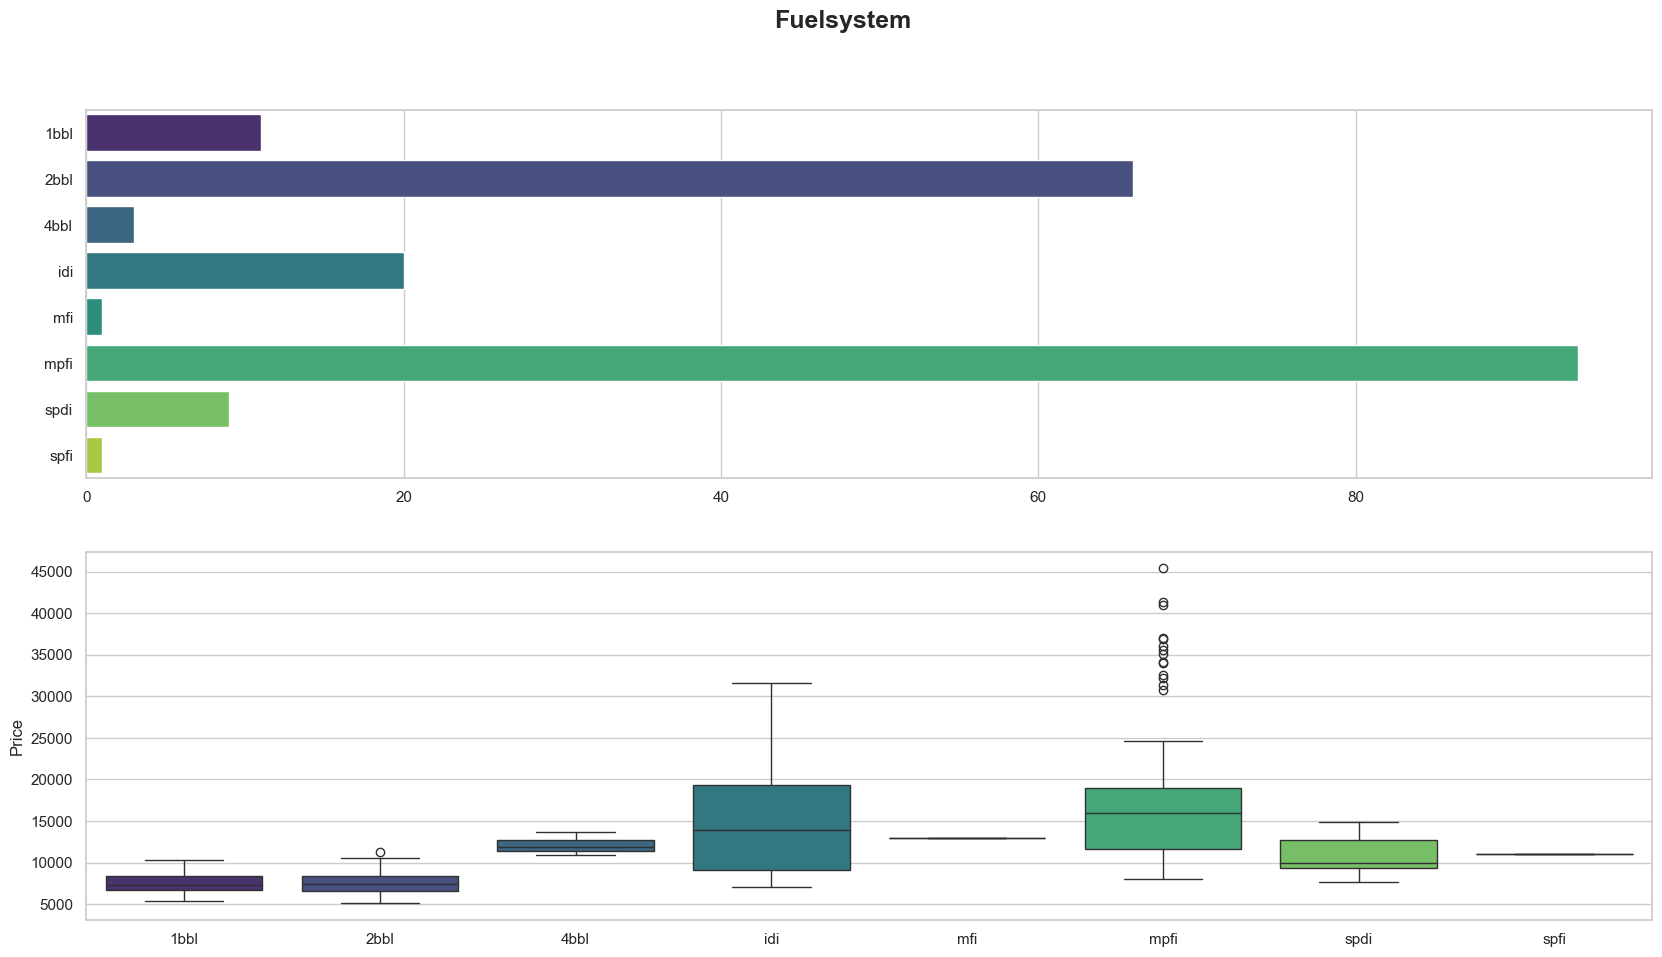

CORRELACIÓN:
Fuelsystem y Price: 0.53


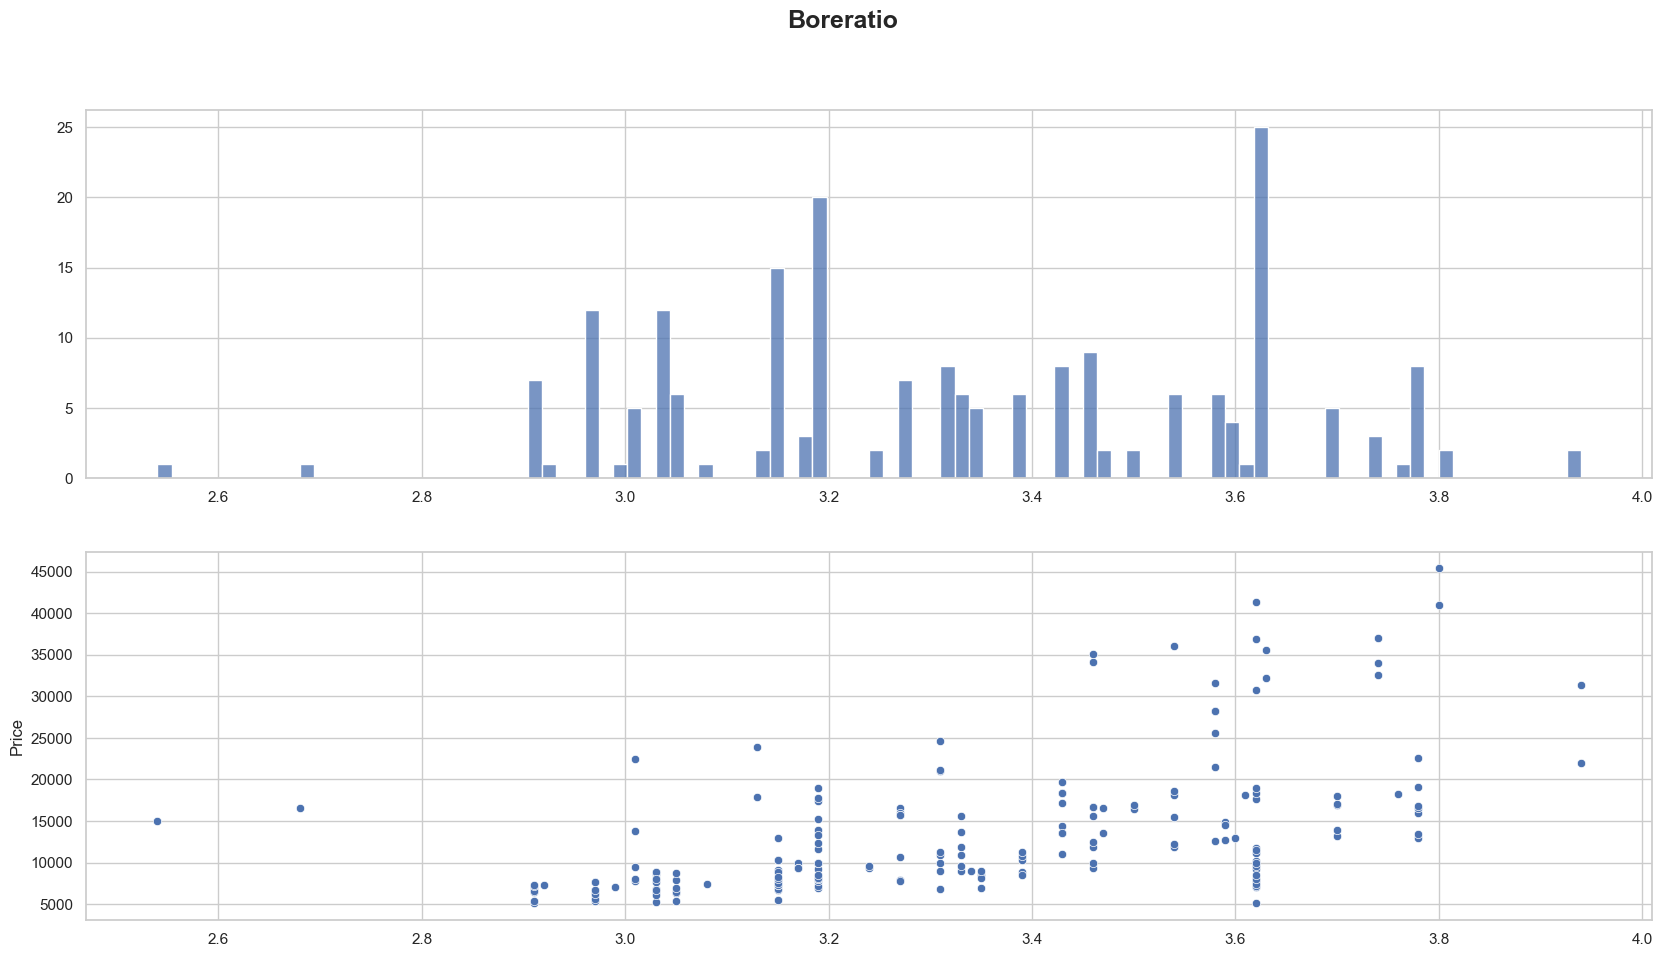

CORRELACIÓN:
Boreratio y Price: 0.55


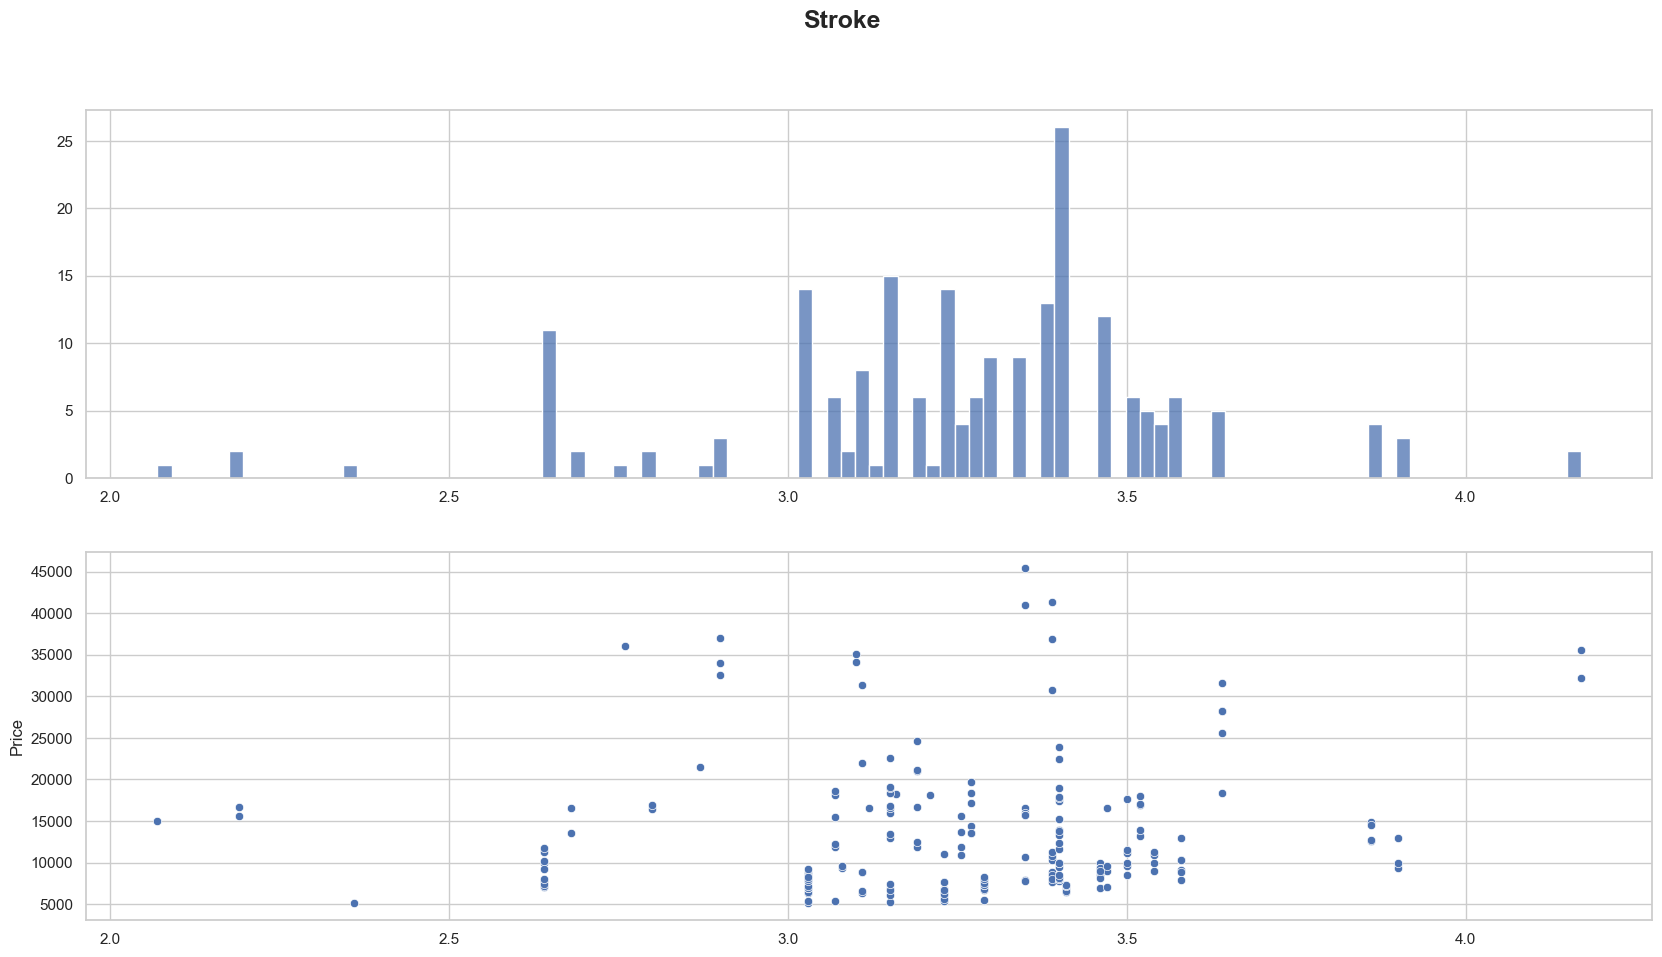

CORRELACIÓN:
Stroke y Price: 0.08


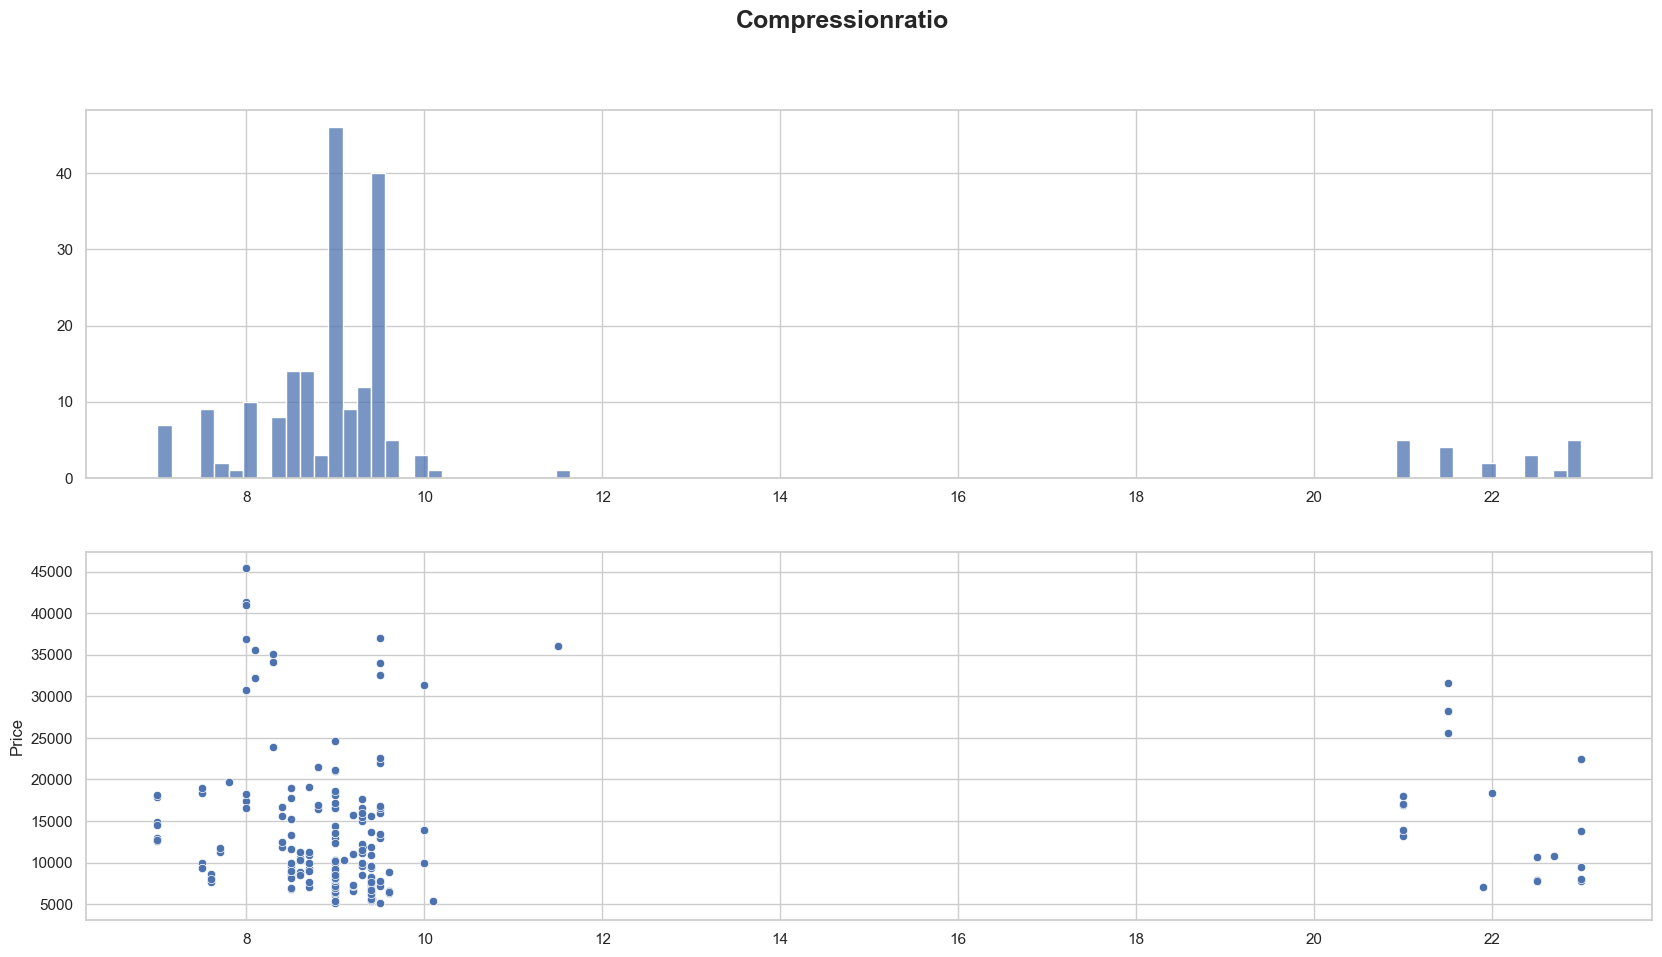

CORRELACIÓN:
Compressionratio y Price: 0.07


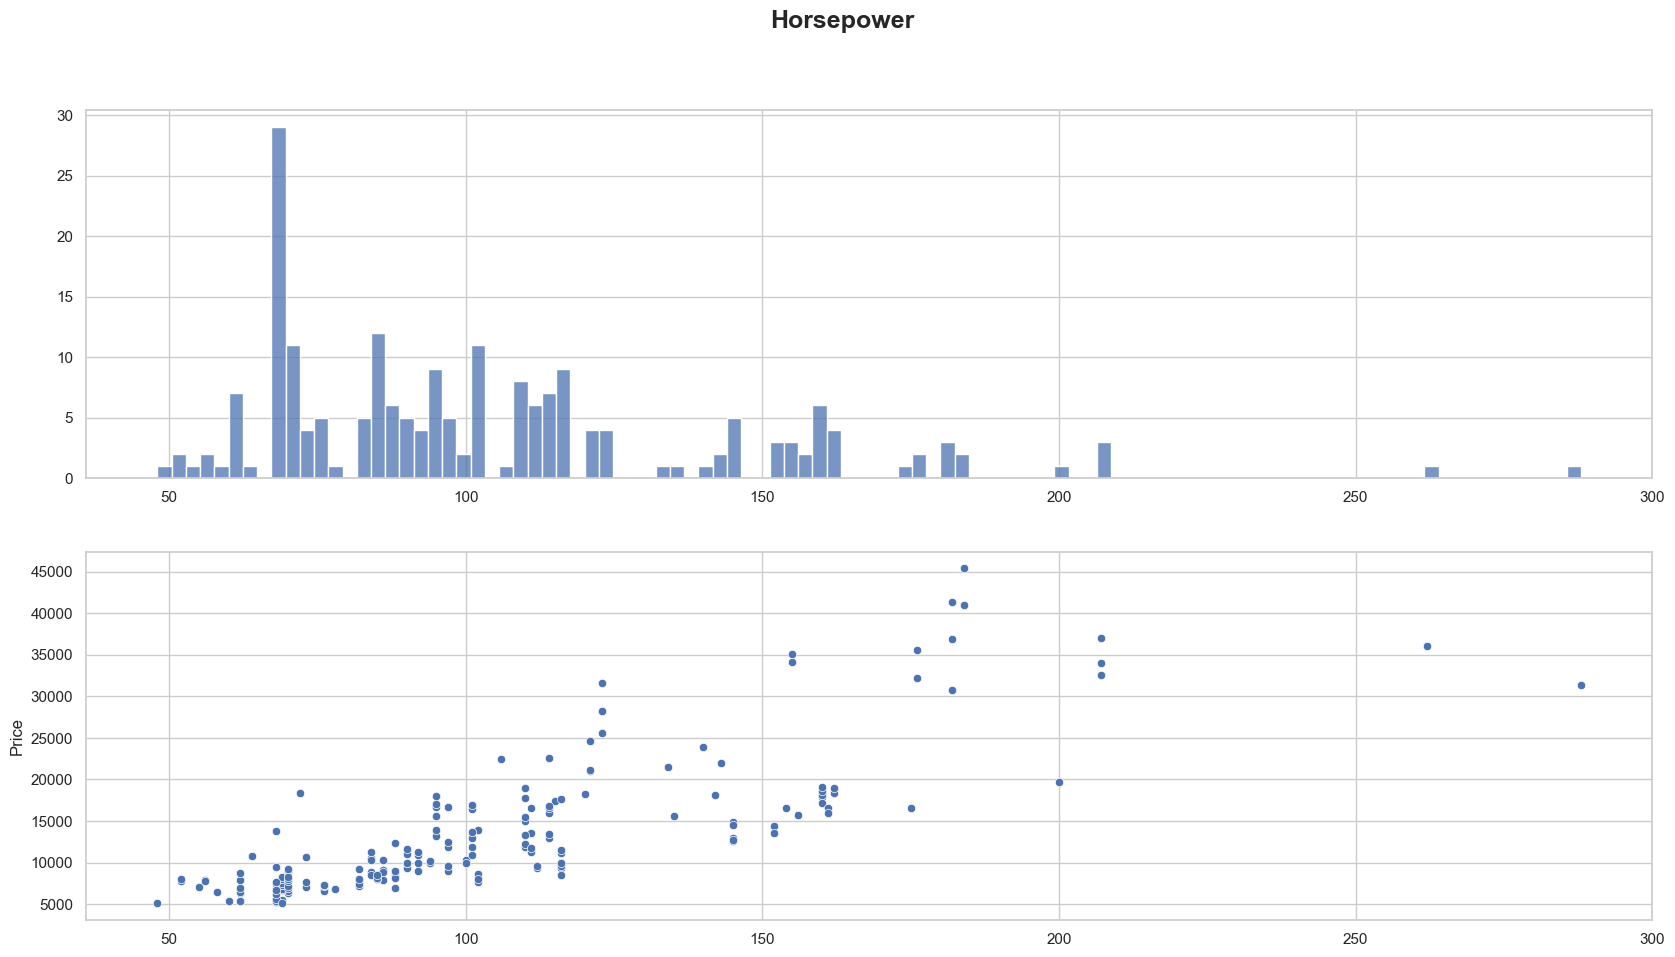

CORRELACIÓN:
Horsepower y Price: 0.81


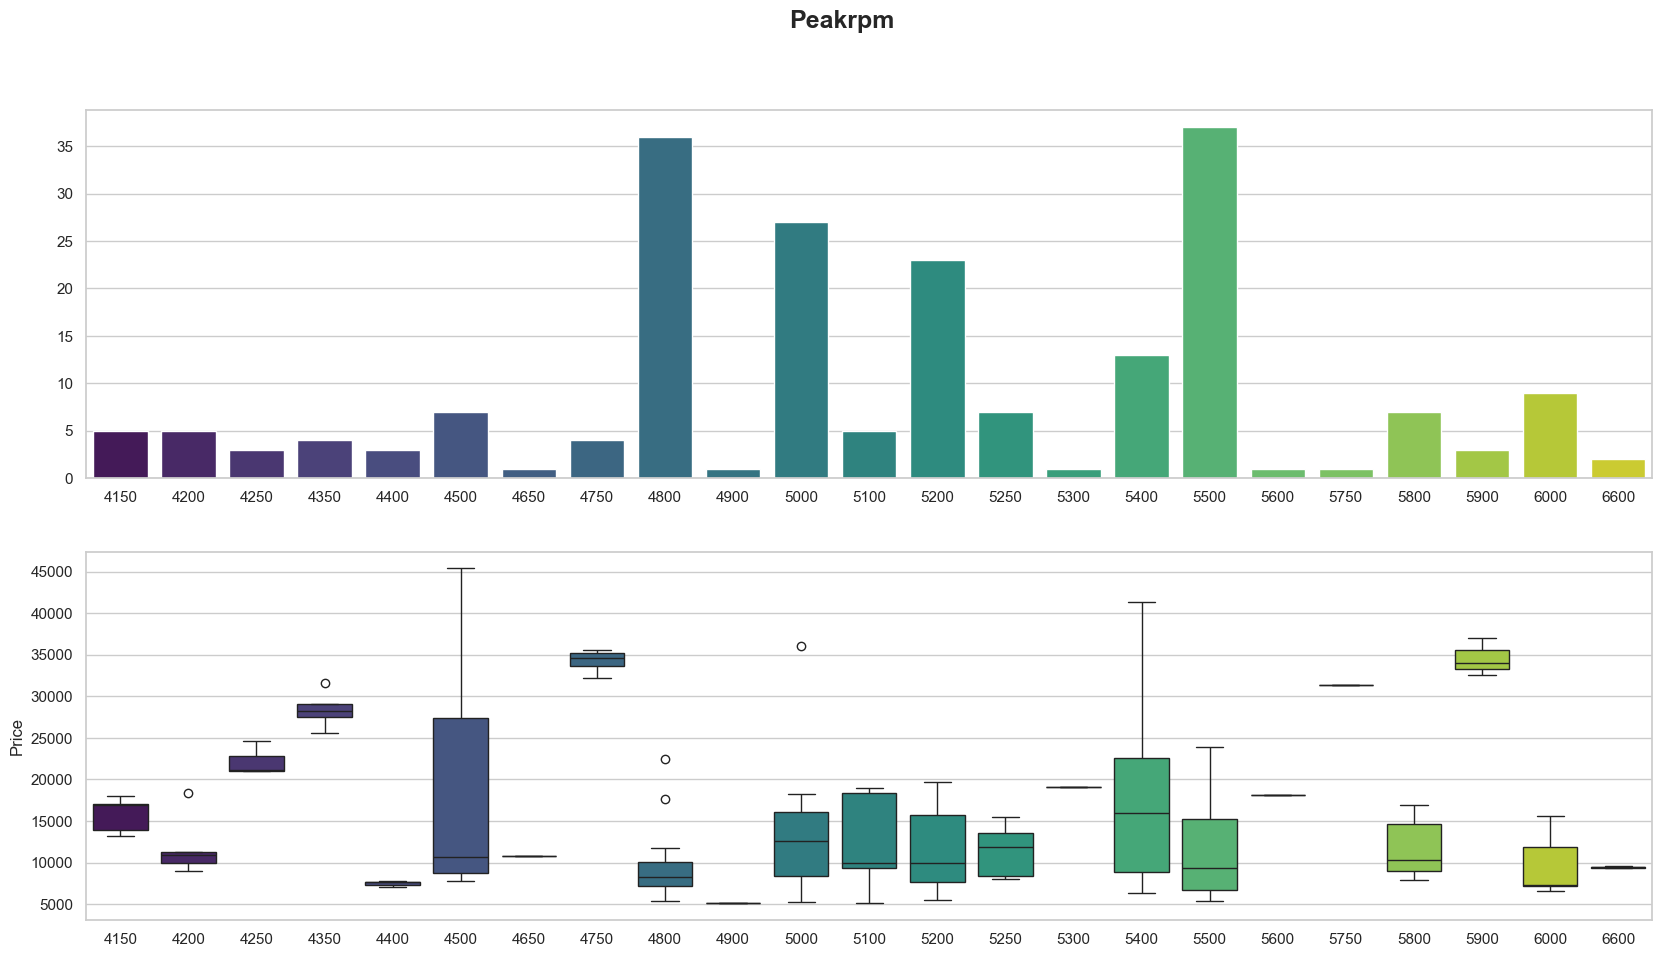

CORRELACIÓN:
Peakrpm y Price: -0.09


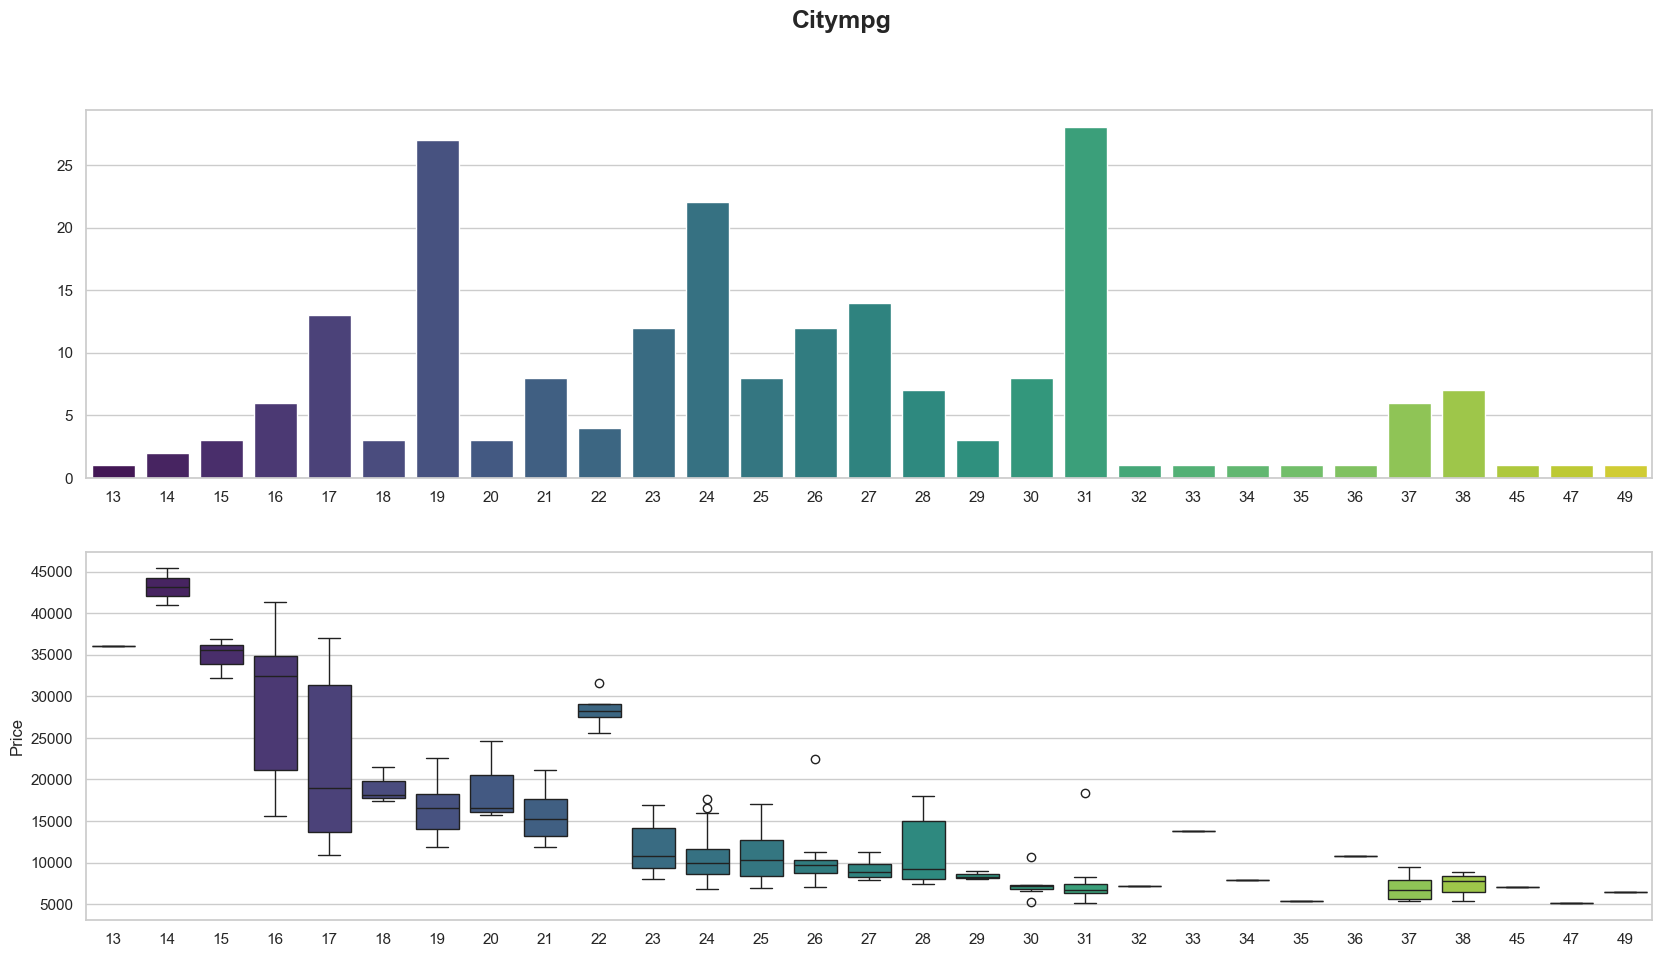

CORRELACIÓN:
Citympg y Price: -0.69


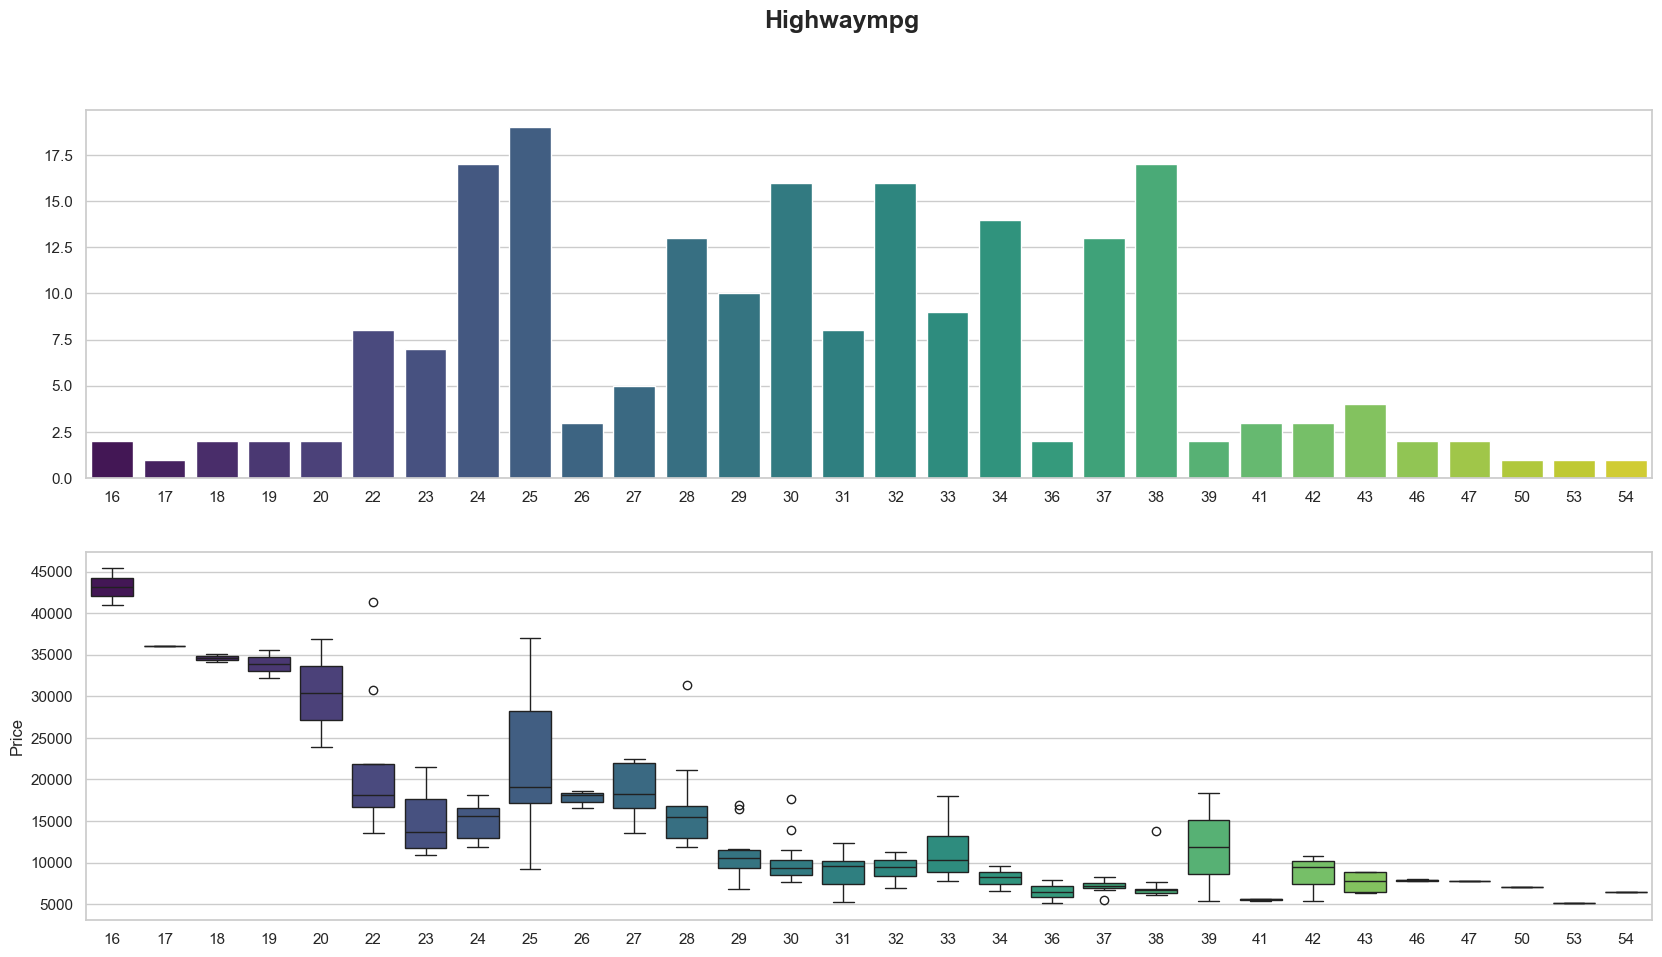

CORRELACIÓN:
Highwaympg y Price: -0.7


In [11]:
if __name__ == "__main__":
    for attr in df.columns[:-1]:
        analysis(attr)